In [1]:
# ============================================================
# STEP 1: MOUNT GOOGLE DRIVE AND DEFINE PATHS
# ============================================================

from google.colab import drive
import os

drive.mount('/content/drive')

# Project paths
PROJECT_ROOT = "/content/drive/MyDrive/angio_ai_project"

# Fine-tuned FR-UNet model
BEST_MODEL_PATH = os.path.join(
    PROJECT_ROOT,
    "AngioLens_FRUNet_Training_Results",
    "best_angioLens_frunet.pth"
)

# Fine-tuning dataset
FINETUNE_DATASET_ROOT = os.path.join(
    PROJECT_ROOT,
    "AngioLens_FRUNet_FineTune"
)

# Training results
TRAINING_RESULTS_ROOT = os.path.join(
    PROJECT_ROOT,
    "AngioLens_FRUNet_Training_Results"
)

print("=" * 70)
print("PATH CHECK")
print("=" * 70)

print("Best model exists:", os.path.exists(BEST_MODEL_PATH))
print("Fine-tuning dataset exists:", os.path.exists(FINETUNE_DATASET_ROOT))
print("Training results exist:", os.path.exists(TRAINING_RESULTS_ROOT))

print("\nBest model path:")
print(BEST_MODEL_PATH)

Mounted at /content/drive
PATH CHECK
Best model exists: True
Fine-tuning dataset exists: True
Training results exist: True

Best model path:
/content/drive/MyDrive/angio_ai_project/AngioLens_FRUNet_Training_Results/best_angioLens_frunet.pth


In [2]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [3]:
# ============================================================
# CHECK TRAINING RESULTS CONTENTS ONLY
# ============================================================

from pathlib import Path

training_results_path = Path(TRAINING_RESULTS_ROOT)

print("=" * 70)
print("TRAINING RESULTS CONTENTS")
print("=" * 70)

for item in sorted(training_results_path.iterdir()):
    if item.is_file():
        size_mb = item.stat().st_size / (1024 ** 2)
        print(f"FILE   | {item.name:<40} | {size_mb:.2f} MB")
    elif item.is_dir():
        print(f"FOLDER | {item.name}/")

TRAINING RESULTS CONTENTS
FILE   | best_angioLens_frunet.pth                | 28.32 MB
FILE   | final_test_ROC_PR_summary.csv            | 0.00 MB
FILE   | final_test_advanced_metrics.csv          | 0.10 MB
FILE   | final_test_bootstrap_95CI.csv            | 0.00 MB
FILE   | final_test_category_summary_threshold_055.csv | 0.00 MB
FILE   | final_test_per_image_metrics_threshold_055.csv | 0.10 MB
FILE   | final_test_pixel_level_PR_curve.png      | 0.10 MB
FILE   | final_test_pixel_level_ROC_curve.png     | 0.13 MB
FILE   | last_angioLens_frunet_checkpoint.pth     | 72.17 MB
FILE   | test_per_image_metrics.csv               | 0.07 MB
FILE   | test_summary.json                        | 0.00 MB
FILE   | training_history.csv                     | 0.01 MB
FILE   | validation_threshold_optimization.csv    | 0.00 MB


In [4]:
# ============================================================
# STEP 2: INSPECT BEST FR-UNET CHECKPOINT
# ============================================================

import torch

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location="cpu",
    weights_only=False
)

print("=" * 70)
print("BEST MODEL CHECKPOINT INSPECTION")
print("=" * 70)

print("Checkpoint type:", type(checkpoint))

if isinstance(checkpoint, dict):
    print("\nCheckpoint keys:")
    for key in checkpoint.keys():
        print(" -", key)

    # Inspect model state dict
    if "model_state_dict" in checkpoint:
        state_dict = checkpoint["model_state_dict"]
    elif "state_dict" in checkpoint:
        state_dict = checkpoint["state_dict"]
    else:
        state_dict = checkpoint

    print("\nNumber of model parameters/tensors:", len(state_dict))

    print("\nFirst 10 state_dict keys:")
    for key in list(state_dict.keys())[:10]:
        print(" -", key)

else:
    print("\nCheckpoint is not a dictionary.")

BEST MODEL CHECKPOINT INSPECTION
Checkpoint type: <class 'dict'>

Checkpoint keys:
 - epoch
 - model_state_dict
 - best_val_dice
 - val_metrics
 - train_metrics
 - settings

Number of model parameters/tensors: 440

First 10 state_dict keys:
 - block1_3.fuse.conv11.weight
 - block1_3.fuse.conv33.weight
 - block1_3.fuse.conv33_di.weight
 - block1_3.fuse.norm.weight
 - block1_3.fuse.norm.bias
 - block1_3.fuse.norm.running_mean
 - block1_3.fuse.norm.running_var
 - block1_3.fuse.norm.num_batches_tracked
 - block1_3.conv.conv.0.weight
 - block1_3.conv.conv.1.weight


In [5]:
# ============================================================
# STEP 3: READ CHECKPOINT METADATA AND SETTINGS
# ============================================================

print("=" * 70)
print("BEST FR-UNET CHECKPOINT METADATA")
print("=" * 70)

print(f"Best epoch      : {checkpoint.get('epoch', 'Not found')}")
print(f"Best Val Dice   : {checkpoint.get('best_val_dice', 'Not found')}")

print("\n" + "=" * 70)
print("MODEL SETTINGS")
print("=" * 70)

settings = checkpoint.get("settings", None)

if settings is None:
    print("No settings found in checkpoint.")
else:
    print("Settings type:", type(settings))
    print()

    if isinstance(settings, dict):
        for key, value in settings.items():
            print(f"{key}: {value}")
    else:
        print(settings)

print("\n" + "=" * 70)
print("VALIDATION METRICS AT BEST EPOCH")
print("=" * 70)

val_metrics = checkpoint.get("val_metrics", None)

if val_metrics is None:
    print("No validation metrics found.")
elif isinstance(val_metrics, dict):
    for key, value in val_metrics.items():
        print(f"{key}: {value}")
else:
    print(val_metrics)

BEST FR-UNET CHECKPOINT METADATA
Best epoch      : 27
Best Val Dice   : 0.9348100168364388

MODEL SETTINGS
Settings type: <class 'dict'>

image_size: 512
batch_size: 2
learning_rate: 1e-05
mask_threshold: 0.5

VALIDATION METRICS AT BEST EPOCH
loss: 0.045622287482461506
bce_loss: 0.014891868007189337
dice_loss: 0.07635270672685959
dice: 0.9348100168364388
iou: 0.8780846022257284
precision: 0.9234261174662775
recall: 0.9472230540103271


In [6]:
# ============================================================
# STEP 4: FAST CHECK FOR FR-UNET ARCHITECTURE
# ============================================================

import os
import sys

print("=" * 70)
print("CHECKING FR-UNET ARCHITECTURE")
print("=" * 70)

# First try direct import
try:
    from models.fr_unet import FR_UNet

    print("FR-UNet import successful ✅")
    print("Model class:", FR_UNet)
    print("Module:", FR_UNet.__module__)

except Exception as e:
    print("Direct import failed.")
    print("Reason:", e)

    # Check only a few likely locations — no full Drive scan
    candidate_paths = [
        "/content/models/fr_unet.py",
        "/content/FR-UNet/models/fr_unet.py",
        "/content/drive/MyDrive/angio_ai_project/models/fr_unet.py",
        "/content/drive/MyDrive/angio_ai_project/FR-UNet/models/fr_unet.py",
    ]

    print("\nChecking likely locations:")

    found = False

    for path in candidate_paths:
        exists = os.path.exists(path)
        print(f"{'✅' if exists else '❌'} {path}")

        if exists:
            found = True

    if not found:
        print("\nFR-UNet architecture was not found in the likely locations.")

CHECKING FR-UNET ARCHITECTURE
Direct import failed.
Reason: No module named 'models'

Checking likely locations:
❌ /content/models/fr_unet.py
❌ /content/FR-UNet/models/fr_unet.py
❌ /content/drive/MyDrive/angio_ai_project/models/fr_unet.py
❌ /content/drive/MyDrive/angio_ai_project/FR-UNet/models/fr_unet.py

FR-UNet architecture was not found in the likely locations.


In [7]:
# ============================================================
# STEP 4: DOWNLOAD AND IMPORT FR-UNET ARCHITECTURE
# ============================================================

%cd /content

# Remove any incomplete previous copy
!rm -rf FR-UNet

# Clone the official FR-UNet repository used previously
!git clone https://github.com/lseventeen/FR-UNet.git

# Move into repository
%cd /content/FR-UNet

# Add repository to Python path
import sys
sys.path.insert(0, "/content/FR-UNet")

# Import the exact FR-UNet architecture
try:
    from models.fr_unet import FR_UNet
    print("\n✅ FR_UNet imported successfully!")
    print("Model class:", FR_UNet)
except Exception as e:
    print("\n❌ FR_UNet import failed:")
    print(type(e).__name__, ":", e)

/content
Cloning into 'FR-UNet'...
remote: Enumerating objects: 154, done.
remote: Counting objects: 100% (50/50), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 154 (delta 35), reused 28 (delta 27), pack-reused 104 (from 2)
Receiving objects: 100% (154/154), 281.79 MiB | 19.05 MiB/s, done.
Resolving deltas: 100% (60/60), done.
Updating files: 100% (22/22), done.
/content/FR-UNet

✅ FR_UNet imported successfully!
Model class: <class 'models.fr_unet.FR_UNet'>


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [8]:
# ============================================================
# STEP 5: CREATE FR-UNET MODEL AND LOAD BEST CHECKPOINT
# ============================================================

import torch

# Select device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 70)
print("LOADING FINE-TUNED FR-UNET MODEL")
print("=" * 70)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# ------------------------------------------------------------
# Create the exact FR-UNet architecture
# ------------------------------------------------------------

model = FR_UNet(
    num_classes=1,
    num_channels=1,
    feature_scale=2,
    dropout=0.2,
    fuse=True,
    out_ave=True
)

# ------------------------------------------------------------
# Load best checkpoint
# ------------------------------------------------------------

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=device,
    weights_only=False
)

model.load_state_dict(
    checkpoint["model_state_dict"],
    strict=True
)

model = model.to(device)
model.eval()

# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

print("\n✅ Fine-tuned FR-UNet loaded successfully!")

print(f"Best epoch      : {checkpoint['epoch']}")
print(f"Best Val Dice   : {checkpoint['best_val_dice']:.6f}")

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(
    p.numel() for p in model.parameters() if p.requires_grad
)

print(f"\nTotal parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

print("\nModel mode:", "Evaluation" if not model.training else "Training")

LOADING FINE-TUNED FR-UNET MODEL
Device: cuda
GPU: Tesla T4

✅ Fine-tuned FR-UNet loaded successfully!
Best epoch      : 27
Best Val Dice   : 0.934810

Total parameters    : 7,374,347
Trainable parameters: 7,374,347

Model mode: Evaluation


In [9]:
# ============================================================
# STEP 6: VERIFY THE EXACT FINE-TUNING DATASET SPLITS
# ============================================================

import os
from pathlib import Path

print("=" * 70)
print("VERIFYING EXACT DATASET SPLITS")
print("=" * 70)

VALID_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

split_info = {}

for split in ["train", "val", "test"]:

    images_dir = Path(FINETUNE_DATASET_ROOT) / split / "images"
    masks_dir  = Path(FINETUNE_DATASET_ROOT) / split / "masks"

    images = sorted([
        p for p in images_dir.iterdir()
        if p.is_file() and p.suffix.lower() in VALID_EXTENSIONS
    ])

    masks = sorted([
        p for p in masks_dir.iterdir()
        if p.is_file() and p.suffix.lower() in VALID_EXTENSIONS
    ])

    split_info[split] = {
        "images_dir": images_dir,
        "masks_dir": masks_dir,
        "images": images,
        "masks": masks
    }

    print(f"\n{split.upper()}")
    print("-" * 40)
    print(f"Images : {len(images)}")
    print(f"Masks  : {len(masks)}")

    if len(images) == len(masks):
        print("Pair count check: ✅")
    else:
        print("Pair count check: ❌")


print("\n" + "=" * 70)
print("EXPECTED COUNTS")
print("=" * 70)

print("Train expected : 2357")
print("Val expected   : 475")
print("Test expected  : 503")

VERIFYING EXACT DATASET SPLITS

TRAIN
----------------------------------------
Images : 0
Masks  : 0
Pair count check: ✅

VAL
----------------------------------------
Images : 0
Masks  : 0
Pair count check: ✅

TEST
----------------------------------------
Images : 0
Masks  : 0
Pair count check: ✅

EXPECTED COUNTS
Train expected : 2357
Val expected   : 475
Test expected  : 503


In [10]:
# ============================================================
# STEP 6A: INSPECT FINE-TUNING DATASET STRUCTURE
# ============================================================

import os
from pathlib import Path

dataset_root = Path(FINETUNE_DATASET_ROOT)

print("=" * 70)
print("FINE-TUNING DATASET STRUCTURE")
print("=" * 70)

print("\nDataset root:")
print(dataset_root)

print("\nRoot exists:", dataset_root.exists())

if dataset_root.exists():

    print("\nImmediate contents:")
    print("-" * 70)

    items = sorted(dataset_root.iterdir())

    for item in items:
        if item.is_dir():
            print(f"📁 FOLDER | {item.name}")
        else:
            size_mb = item.stat().st_size / (1024 ** 2)
            print(f"📄 FILE   | {item.name} | {size_mb:.2f} MB")

    print("\n" + "=" * 70)
    print("ONE LEVEL INSIDE EACH FOLDER")
    print("=" * 70)

    for item in items:
        if item.is_dir():

            print(f"\n📁 {item.name}/")

            try:
                children = sorted(item.iterdir())

                for child in children[:30]:
                    if child.is_dir():
                        print(f"    📁 {child.name}/")
                    else:
                        print(f"    📄 {child.name}")

                if len(children) > 30:
                    print(f"    ... and {len(children) - 30} more items")

            except Exception as e:
                print("    Could not inspect:", e)

else:
    print("\n❌ Dataset root does not exist.")

FINE-TUNING DATASET STRUCTURE

Dataset root:
/content/drive/MyDrive/angio_ai_project/AngioLens_FRUNet_FineTune

Root exists: True

Immediate contents:
----------------------------------------------------------------------
📄 FILE   | accepted_split_manifest.csv | 2.43 MB
📄 FILE   | split_summary.csv | 0.00 MB
📁 FOLDER | test
📁 FOLDER | train
📁 FOLDER | val

ONE LEVEL INSIDE EACH FOLDER

📁 test/
    📁 images/
    📁 masks/

📁 train/
    📁 images/
    📁 masks/

📁 val/
    📁 images/
    📁 masks/


In [11]:
# ============================================================
# STEP 6B: CHECK ACTUAL FILE NAMES AND EXTENSIONS
# ============================================================

from pathlib import Path

print("=" * 70)
print("CHECKING ACTUAL FILES AND EXTENSIONS")
print("=" * 70)

for split in ["train", "val", "test"]:

    images_dir = Path(FINETUNE_DATASET_ROOT) / split / "images"
    masks_dir  = Path(FINETUNE_DATASET_ROOT) / split / "masks"

    image_files = list(images_dir.iterdir())
    mask_files  = list(masks_dir.iterdir())

    print(f"\n{split.upper()}")
    print("-" * 50)

    print(f"Total items in images folder: {len(image_files)}")
    print(f"Total items in masks folder : {len(mask_files)}")

    print("\nFirst 5 image files:")
    for file in image_files[:5]:
        print(f"  {file.name}")

    print("\nFirst 5 mask files:")
    for file in mask_files[:5]:
        print(f"  {file.name}")

    print("\nImage extensions found:")
    print(sorted(set(file.suffix.lower() for file in image_files if file.is_file())))

    print("Mask extensions found:")
    print(sorted(set(file.suffix.lower() for file in mask_files if file.is_file())))


print("\n" + "=" * 70)
print("CHECK COMPLETED")
print("=" * 70)

CHECKING ACTUAL FILES AND EXTENSIONS

TRAIN
--------------------------------------------------
Total items in images folder: 4
Total items in masks folder : 4

First 5 image files:
  Normal
  Post-treatment
  Pre-treatment
  Unique Stenosis Views

First 5 mask files:
  Normal
  Post-treatment
  Pre-treatment
  Unique Stenosis Views

Image extensions found:
[]
Mask extensions found:
[]

VAL
--------------------------------------------------
Total items in images folder: 4
Total items in masks folder : 4

First 5 image files:
  Normal
  Post-treatment
  Pre-treatment
  Unique Stenosis Views

First 5 mask files:
  Normal
  Post-treatment
  Pre-treatment
  Unique Stenosis Views

Image extensions found:
[]
Mask extensions found:
[]

TEST
--------------------------------------------------
Total items in images folder: 4
Total items in masks folder : 4

First 5 image files:
  Normal
  Post-treatment
  Pre-treatment
  Unique Stenosis Views

First 5 mask files:
  Normal
  Post-treatment
  Pre-t

In [12]:
# ============================================================
# STEP 6C: VERIFY EXACT DATASET COUNTS RECURSIVELY
# ============================================================

from pathlib import Path
from collections import Counter

print("=" * 70)
print("VERIFYING EXACT DATASET COUNTS RECURSIVELY")
print("=" * 70)

VALID_EXTENSIONS = {
    ".png", ".jpg", ".jpeg",
    ".bmp", ".tif", ".tiff"
}

split_info = {}

for split in ["train", "val", "test"]:

    images_dir = Path(FINETUNE_DATASET_ROOT) / split / "images"
    masks_dir  = Path(FINETUNE_DATASET_ROOT) / split / "masks"

    # Recursive search inside all category folders
    images = sorted([
        p for p in images_dir.rglob("*")
        if p.is_file() and p.suffix.lower() in VALID_EXTENSIONS
    ])

    masks = sorted([
        p for p in masks_dir.rglob("*")
        if p.is_file() and p.suffix.lower() in VALID_EXTENSIONS
    ])

    split_info[split] = {
        "images_dir": images_dir,
        "masks_dir": masks_dir,
        "images": images,
        "masks": masks
    }

    # Count images and masks by category
    image_categories = Counter(
        p.relative_to(images_dir).parts[0]
        for p in images
    )

    mask_categories = Counter(
        p.relative_to(masks_dir).parts[0]
        for p in masks
    )

    print(f"\n{'=' * 70}")
    print(split.upper())
    print("=" * 70)

    print(f"Total images : {len(images)}")
    print(f"Total masks  : {len(masks)}")

    print("\nImages by category:")
    for category, count in sorted(image_categories.items()):
        print(f"  {category:<25}: {count}")

    print("\nMasks by category:")
    for category, count in sorted(mask_categories.items()):
        print(f"  {category:<25}: {count}")

    if len(images) == len(masks):
        print("\nPair count check: ✅")
    else:
        print("\nPair count check: ❌")


print("\n" + "=" * 70)
print("EXPECTED TOTALS")
print("=" * 70)

expected = {
    "train": 2357,
    "val": 475,
    "test": 503
}

all_correct = True

for split, expected_count in expected.items():

    actual_images = len(split_info[split]["images"])
    actual_masks  = len(split_info[split]["masks"])

    correct = (
        actual_images == expected_count
        and actual_masks == expected_count
    )

    status = "✅" if correct else "❌"

    print(
        f"{split:<6}: "
        f"Expected = {expected_count:<4} | "
        f"Images = {actual_images:<4} | "
        f"Masks = {actual_masks:<4} {status}"
    )

    if not correct:
        all_correct = False


print("\n" + "=" * 70)

if all_correct:
    print("ALL DATASET SPLITS VERIFIED SUCCESSFULLY ✅")
else:
    print("DATASET COUNT MISMATCH DETECTED ❌")

print("=" * 70)

VERIFYING EXACT DATASET COUNTS RECURSIVELY

TRAIN
Total images : 2357
Total masks  : 2357

Images by category:
  Normal                   : 107
  Post-treatment           : 794
  Pre-treatment            : 910
  Unique Stenosis Views    : 546

Masks by category:
  Normal                   : 107
  Post-treatment           : 794
  Pre-treatment            : 910
  Unique Stenosis Views    : 546

Pair count check: ✅

VAL
Total images : 475
Total masks  : 475

Images by category:
  Normal                   : 31
  Post-treatment           : 179
  Pre-treatment            : 168
  Unique Stenosis Views    : 97

Masks by category:
  Normal                   : 31
  Post-treatment           : 179
  Pre-treatment            : 168
  Unique Stenosis Views    : 97

Pair count check: ✅

TEST
Total images : 503
Total masks  : 503

Images by category:
  Normal                   : 25
  Post-treatment           : 160
  Pre-treatment            : 191
  Unique Stenosis Views    : 127

Masks by category:
  N

In [13]:
# ============================================================
# STEP 7: CREATE EXACT EVALUATION DATASET AND DATALOADERS
# Same preprocessing used during FR-UNet fine-tuning
# ============================================================

import cv2
import numpy as np
import torch

from pathlib import Path
from torch.utils.data import Dataset, DataLoader


# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

IMAGE_SIZE = 512
BATCH_SIZE = 2
NUM_WORKERS = 2

SUPPORTED_EXTENSIONS = {
    ".png",
    ".jpg",
    ".jpeg",
    ".bmp",
    ".tif",
    ".tiff"
}


# ------------------------------------------------------------
# EXACT DATASET CLASS USED FOR EVALUATION
# ------------------------------------------------------------

class AngioLensEvaluationDataset(Dataset):

    def __init__(self, split_root, image_size=512):

        self.split_root = Path(split_root)

        self.images_root = (
            self.split_root / "images"
        )

        self.masks_root = (
            self.split_root / "masks"
        )

        self.image_size = image_size

        self.samples = []

        for image_path in sorted(
            self.images_root.rglob("*")
        ):

            if (
                image_path.is_file()
                and image_path.suffix.lower()
                in SUPPORTED_EXTENSIONS
            ):

                relative_path = (
                    image_path.relative_to(
                        self.images_root
                    )
                )

                mask_path = (
                    self.masks_root
                    / relative_path.with_suffix(".png")
                )

                if mask_path.exists():

                    self.samples.append({
                        "image_path": image_path,
                        "mask_path": mask_path,
                        "relative_path": (
                            relative_path.as_posix()
                        )
                    })

        if len(self.samples) == 0:

            raise RuntimeError(
                f"No image-mask pairs found in:\n"
                f"{self.split_root}"
            )

        print(
            f"{self.split_root.name}: "
            f"{len(self.samples)} pairs"
        )


    def __len__(self):

        return len(self.samples)


    def normalize_image(self, image):

        image = (
            image.astype(np.float32)
            / 255.0
        )

        mean = float(image.mean())
        std = float(image.std())

        image = (
            image - mean
        ) / (
            std + 1e-8
        )

        image = (
            image - image.min()
        ) / (
            image.max()
            - image.min()
            + 1e-8
        )

        return image.astype(np.float32)


    def __getitem__(self, index):

        sample = self.samples[index]

        image = cv2.imread(
            str(sample["image_path"]),
            cv2.IMREAD_GRAYSCALE
        )

        mask = cv2.imread(
            str(sample["mask_path"]),
            cv2.IMREAD_GRAYSCALE
        )

        if image is None:
            raise FileNotFoundError(
                sample["image_path"]
            )

        if mask is None:
            raise FileNotFoundError(
                sample["mask_path"]
            )

        image = cv2.resize(
            image,
            (
                self.image_size,
                self.image_size
            ),
            interpolation=cv2.INTER_LINEAR
        )

        mask = cv2.resize(
            mask,
            (
                self.image_size,
                self.image_size
            ),
            interpolation=cv2.INTER_NEAREST
        )

        mask = (
            mask > 127
        ).astype(np.float32)

        image = self.normalize_image(image)

        image_tensor = (
            torch.from_numpy(image)
            .unsqueeze(0)
            .float()
        )

        mask_tensor = (
            torch.from_numpy(mask.copy())
            .unsqueeze(0)
            .float()
        )

        return {
            "image": image_tensor,
            "mask": mask_tensor,
            "relative_path": sample["relative_path"]
        }


# ------------------------------------------------------------
# CREATE VALIDATION AND TEST DATASETS ONLY
# No need to load train set for final evaluation
# ------------------------------------------------------------

val_dataset = AngioLensEvaluationDataset(
    Path(FINETUNE_DATASET_ROOT) / "val",
    image_size=IMAGE_SIZE
)

test_dataset = AngioLensEvaluationDataset(
    Path(FINETUNE_DATASET_ROOT) / "test",
    image_size=IMAGE_SIZE
)


# ------------------------------------------------------------
# CREATE DATALOADERS
# ------------------------------------------------------------

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0)
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0)
)


# ------------------------------------------------------------
# FINAL VERIFICATION
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("EVALUATION DATASET READY")
print("=" * 70)

print(f"Validation images : {len(val_dataset)}")
print(f"Test images       : {len(test_dataset)}")

print(f"\nValidation batches: {len(val_loader)}")
print(f"Test batches      : {len(test_loader)}")

print("\nExpected:")
print("Validation images : 475")
print("Test images       : 503")

if (
    len(val_dataset) == 475
    and len(test_dataset) == 503
):
    print(
        "\n✅ Exact validation and test splits "
        "loaded successfully!"
    )
else:
    print(
        "\n❌ Dataset count mismatch detected."
    )

val: 475 pairs
test: 503 pairs

EVALUATION DATASET READY
Validation images : 475
Test images       : 503

Validation batches: 238
Test batches      : 252

Expected:
Validation images : 475
Test images       : 503

✅ Exact validation and test splits loaded successfully!


In [14]:
# ============================================================
# STEP 8: RUN VALIDATION INFERENCE
# Collect probability maps and ground-truth masks
# ============================================================

import time
import numpy as np
import torch

from tqdm.auto import tqdm


print("=" * 70)
print("RUNNING VALIDATION INFERENCE")
print("=" * 70)

print(f"Device            : {device}")
print(f"Validation images : {len(val_dataset)}")
print(f"Validation batches: {len(val_loader)}")


# ------------------------------------------------------------
# STORAGE
# ------------------------------------------------------------

val_probabilities = []
val_ground_truths = []
val_relative_paths = []


# ------------------------------------------------------------
# INFERENCE
# ------------------------------------------------------------

model.eval()

start_time = time.time()

with torch.inference_mode():

    for batch in tqdm(
        val_loader,
        desc="Validation inference"
    ):

        images = batch["image"].to(
            device,
            non_blocking=True
        )

        masks = batch["mask"]

        # Forward pass
        outputs = model(images)

        # Handle model output safely
        if isinstance(outputs, (list, tuple)):
            outputs = outputs[-1]

        # Convert logits to probabilities
        probabilities = torch.sigmoid(outputs)

        # Move results to CPU
        probabilities = (
            probabilities
            .detach()
            .cpu()
            .numpy()
        )

        masks = (
            masks
            .detach()
            .cpu()
            .numpy()
        )

        # Save every image separately
        for i in range(probabilities.shape[0]):

            val_probabilities.append(
                probabilities[i, 0].astype(np.float32)
            )

            val_ground_truths.append(
                masks[i, 0].astype(np.uint8)
            )

        val_relative_paths.extend(
            list(batch["relative_path"])
        )


# ------------------------------------------------------------
# CONVERT TO NUMPY ARRAYS
# ------------------------------------------------------------

val_probabilities = np.stack(
    val_probabilities,
    axis=0
)

val_ground_truths = np.stack(
    val_ground_truths,
    axis=0
)


# ------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------

elapsed_time = time.time() - start_time

print("\n" + "=" * 70)
print("VALIDATION INFERENCE COMPLETED")
print("=" * 70)

print(
    f"Probability maps shape : "
    f"{val_probabilities.shape}"
)

print(
    f"Ground-truth masks shape: "
    f"{val_ground_truths.shape}"
)

print(
    f"Relative paths collected: "
    f"{len(val_relative_paths)}"
)

print(
    f"Probability range        : "
    f"[{val_probabilities.min():.6f}, "
    f"{val_probabilities.max():.6f}]"
)

print(
    f"Total inference time     : "
    f"{elapsed_time / 60:.2f} minutes"
)

print(
    f"Average time per image   : "
    f"{elapsed_time / len(val_dataset):.4f} seconds"
)


# ------------------------------------------------------------
# FINAL CHECK
# ------------------------------------------------------------

if (
    val_probabilities.shape[0] == 475
    and val_ground_truths.shape[0] == 475
    and len(val_relative_paths) == 475
):

    print(
        "\n✅ Validation inference completed "
        "successfully for all 475 images!"
    )

else:

    print(
        "\n❌ Validation inference count mismatch!"
    )

RUNNING VALIDATION INFERENCE
Device            : cuda
Validation images : 475
Validation batches: 238


Validation inference:   0%|          | 0/238 [00:00<?, ?it/s]


VALIDATION INFERENCE COMPLETED
Probability maps shape : (475, 512, 512)
Ground-truth masks shape: (475, 512, 512)
Relative paths collected: 475
Probability range        : [0.000000, 1.000000]
Total inference time     : 7.08 minutes
Average time per image   : 0.8943 seconds

✅ Validation inference completed successfully for all 475 images!


In [15]:
# ============================================================
# STEP 9: OPTIMIZE SEGMENTATION THRESHOLD ON VALIDATION SET
# Fast vectorized evaluation
# ============================================================

import numpy as np
import pandas as pd
import time

print("=" * 70)
print("VALIDATION THRESHOLD OPTIMIZATION")
print("=" * 70)

# ------------------------------------------------------------
# THRESHOLDS TO TEST
# ------------------------------------------------------------

thresholds = np.arange(0.10, 0.91, 0.05)

results = []

start_time = time.time()

# Ground truth is fixed
gt = val_ground_truths.astype(bool)

for threshold in thresholds:

    pred = val_probabilities >= threshold

    # Per-image intersection and sums
    intersection = np.sum(
        pred & gt,
        axis=(1, 2)
    ).astype(np.float64)

    pred_sum = np.sum(
        pred,
        axis=(1, 2)
    ).astype(np.float64)

    gt_sum = np.sum(
        gt,
        axis=(1, 2)
    ).astype(np.float64)

    union = pred_sum + gt_sum - intersection

    # Per-image Dice
    dice = (
        (2.0 * intersection + 1e-7)
        / (pred_sum + gt_sum + 1e-7)
    )

    # Per-image IoU
    iou = (
        (intersection + 1e-7)
        / (union + 1e-7)
    )

    results.append({
        "Threshold": float(threshold),
        "Mean_Dice": float(np.mean(dice)),
        "Std_Dice": float(np.std(dice)),
        "Mean_IoU": float(np.mean(iou)),
        "Std_IoU": float(np.std(iou))
    })


# ------------------------------------------------------------
# RESULTS TABLE
# ------------------------------------------------------------

threshold_results = pd.DataFrame(results)

best_index = threshold_results[
    "Mean_Dice"
].idxmax()

best_threshold = float(
    threshold_results.loc[
        best_index,
        "Threshold"
    ]
)

best_dice = float(
    threshold_results.loc[
        best_index,
        "Mean_Dice"
    ]
)

best_iou = float(
    threshold_results.loc[
        best_index,
        "Mean_IoU"
    ]
)


# ------------------------------------------------------------
# DISPLAY
# ------------------------------------------------------------

print("\nThreshold results:")
print(
    threshold_results.to_string(
        index=False,
        float_format=lambda x: f"{x:.6f}"
    )
)

print("\n" + "=" * 70)
print("BEST VALIDATION THRESHOLD")
print("=" * 70)

print(f"Best threshold : {best_threshold:.2f}")
print(f"Mean Dice      : {best_dice:.6f}")
print(f"Mean IoU       : {best_iou:.6f}")

elapsed = time.time() - start_time

print(f"\nOptimization time: {elapsed:.2f} seconds")


# ------------------------------------------------------------
# COMPARE WITH ORIGINAL 0.50 THRESHOLD
# ------------------------------------------------------------

original_row = threshold_results[
    np.isclose(
        threshold_results["Threshold"],
        0.50
    )
].iloc[0]

print("\n" + "=" * 70)
print("COMPARISON WITH ORIGINAL THRESHOLD = 0.50")
print("=" * 70)

print(
    f"Original 0.50 Dice : "
    f"{original_row['Mean_Dice']:.6f}"
)

print(
    f"Optimized Dice     : "
    f"{best_dice:.6f}"
)

print(
    f"Dice improvement   : "
    f"{best_dice - original_row['Mean_Dice']:+.6f}"
)


# ------------------------------------------------------------
# SAVE RESULTS
# ------------------------------------------------------------

threshold_output_path = (
    Path(TRAINING_RESULTS_ROOT)
    / "validation_threshold_optimization.csv"
)

threshold_results.to_csv(
    threshold_output_path,
    index=False
)

print(
    f"\nResults saved to:\n"
    f"{threshold_output_path}"
)

print("\n✅ Threshold optimization completed successfully!")

VALIDATION THRESHOLD OPTIMIZATION

Threshold results:
 Threshold  Mean_Dice  Std_Dice  Mean_IoU  Std_IoU
  0.100000   0.919538  0.021872  0.851805 0.036839
  0.150000   0.924785  0.020700  0.860770 0.035188
  0.200000   0.928085  0.019878  0.866449 0.033981
  0.250000   0.930383  0.019274  0.870424 0.033071
  0.300000   0.932059  0.018699  0.873327 0.032194
  0.350000   0.933213  0.018181  0.875322 0.031369
  0.400000   0.934060  0.017852  0.876795 0.030842
  0.450000   0.934622  0.017506  0.877765 0.030274
  0.500000   0.934951  0.017209  0.878330 0.029784
  0.550000   0.935089  0.016935  0.878557 0.029319
  0.600000   0.934961  0.016767  0.878321 0.029015
  0.650000   0.934505  0.016633  0.877511 0.028762
  0.700000   0.933801  0.016525  0.876265 0.028538
  0.750000   0.932616  0.016470  0.874177 0.028385
  0.800000   0.930804  0.016559  0.871004 0.028435
  0.850000   0.927849  0.016771  0.865856 0.028638
  0.900000   0.922475  0.017451  0.856582 0.029488

BEST VALIDATION THRESHOLD
B

In [16]:
# ============================================================
# STEP 10: FINAL TEST INFERENCE AND PER-IMAGE METRICS
# Uses the validation-selected threshold = 0.55
# ============================================================

import time
import numpy as np
import pandas as pd
import torch

from tqdm.auto import tqdm
from pathlib import Path


# ------------------------------------------------------------
# FIXED THRESHOLD SELECTED ON VALIDATION SET
# ------------------------------------------------------------

FINAL_THRESHOLD = best_threshold

print("=" * 70)
print("FINAL TEST INFERENCE")
print("=" * 70)

print(f"Device             : {device}")
print(f"Test images        : {len(test_dataset)}")
print(f"Test batches       : {len(test_loader)}")
print(f"Selected threshold : {FINAL_THRESHOLD:.2f}")


# ------------------------------------------------------------
# STORAGE
# ------------------------------------------------------------

test_probabilities = []
test_ground_truths = []
test_predictions = []
test_relative_paths = []

per_image_results = []


# ------------------------------------------------------------
# INFERENCE
# ------------------------------------------------------------

model.eval()

start_time = time.time()

with torch.inference_mode():

    for batch in tqdm(
        test_loader,
        desc="Final test inference"
    ):

        images = batch["image"].to(
            device,
            non_blocking=True
        )

        masks = batch["mask"]

        # Forward pass
        outputs = model(images)

        if isinstance(outputs, (list, tuple)):
            outputs = outputs[-1]

        probabilities = torch.sigmoid(outputs)

        # Move to CPU
        probabilities = (
            probabilities
            .detach()
            .cpu()
            .numpy()
        )

        masks = (
            masks
            .detach()
            .cpu()
            .numpy()
        )

        relative_paths = list(
            batch["relative_path"]
        )

        # ----------------------------------------------------
        # PROCESS EACH IMAGE
        # ----------------------------------------------------

        for i in range(probabilities.shape[0]):

            probability_map = (
                probabilities[i, 0]
                .astype(np.float32)
            )

            ground_truth = (
                masks[i, 0] > 0.5
            )

            prediction = (
                probability_map >= FINAL_THRESHOLD
            )

            # -----------------------------------------------
            # Pixel counts
            # -----------------------------------------------

            tp = np.sum(
                prediction & ground_truth
            )

            fp = np.sum(
                prediction & (~ground_truth)
            )

            fn = np.sum(
                (~prediction) & ground_truth
            )

            tn = np.sum(
                (~prediction) & (~ground_truth)
            )

            # -----------------------------------------------
            # Metrics
            # -----------------------------------------------

            dice = (
                (2.0 * tp + 1e-7)
                / (
                    2.0 * tp
                    + fp
                    + fn
                    + 1e-7
                )
            )

            iou = (
                (tp + 1e-7)
                / (
                    tp
                    + fp
                    + fn
                    + 1e-7
                )
            )

            precision = (
                (tp + 1e-7)
                / (
                    tp
                    + fp
                    + 1e-7
                )
            )

            recall = (
                (tp + 1e-7)
                / (
                    tp
                    + fn
                    + 1e-7
                )
            )

            specificity = (
                (tn + 1e-7)
                / (
                    tn
                    + fp
                    + 1e-7
                )
            )

            accuracy = (
                (tp + tn)
                / (
                    tp
                    + tn
                    + fp
                    + fn
                )
            )

            relative_path = relative_paths[i]

            # Category is first folder in relative path
            category = Path(
                relative_path
            ).parts[0]

            # -----------------------------------------------
            # Save arrays
            # -----------------------------------------------

            test_probabilities.append(
                probability_map
            )

            test_ground_truths.append(
                ground_truth.astype(np.uint8)
            )

            test_predictions.append(
                prediction.astype(np.uint8)
            )

            test_relative_paths.append(
                relative_path
            )

            # -----------------------------------------------
            # Save per-image metrics
            # -----------------------------------------------

            per_image_results.append({
                "Relative_Path": relative_path,
                "Category": category,
                "Threshold": FINAL_THRESHOLD,

                "TP": int(tp),
                "FP": int(fp),
                "FN": int(fn),
                "TN": int(tn),

                "Dice": float(dice),
                "IoU": float(iou),
                "Precision": float(precision),
                "Recall": float(recall),
                "Specificity": float(specificity),
                "Accuracy": float(accuracy)
            })


# ------------------------------------------------------------
# CONVERT ARRAYS
# ------------------------------------------------------------

test_probabilities = np.stack(
    test_probabilities,
    axis=0
)

test_ground_truths = np.stack(
    test_ground_truths,
    axis=0
)

test_predictions = np.stack(
    test_predictions,
    axis=0
)

test_results_df = pd.DataFrame(
    per_image_results
)


# ------------------------------------------------------------
# FINAL SUMMARY
# ------------------------------------------------------------

elapsed_time = time.time() - start_time

print("\n" + "=" * 70)
print("FINAL TEST INFERENCE COMPLETED")
print("=" * 70)

print(
    f"Probability maps shape : "
    f"{test_probabilities.shape}"
)

print(
    f"Ground-truth shape     : "
    f"{test_ground_truths.shape}"
)

print(
    f"Predictions shape      : "
    f"{test_predictions.shape}"
)

print(
    f"Images processed       : "
    f"{len(test_results_df)}"
)

print(
    f"\nTotal inference time   : "
    f"{elapsed_time / 60:.2f} minutes"
)

print(
    f"Average time per image : "
    f"{elapsed_time / len(test_dataset):.4f} seconds"
)


# ------------------------------------------------------------
# MEAN TEST METRICS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL TEST METRICS — THRESHOLD {:.2f}".format(
    FINAL_THRESHOLD
))
print("=" * 70)

metric_columns = [
    "Dice",
    "IoU",
    "Precision",
    "Recall",
    "Specificity",
    "Accuracy"
]

for metric in metric_columns:

    mean_value = test_results_df[
        metric
    ].mean()

    std_value = test_results_df[
        metric
    ].std()

    print(
        f"{metric:<12}: "
        f"{mean_value:.6f} ± "
        f"{std_value:.6f}"
    )


# ------------------------------------------------------------
# CATEGORY SUMMARY
# ------------------------------------------------------------

category_summary = (
    test_results_df
    .groupby("Category")[
        metric_columns
    ]
    .agg(["mean", "std", "count"])
)

print("\n" + "=" * 70)
print("TEST RESULTS BY CATEGORY")
print("=" * 70)

for category in sorted(
    test_results_df["Category"].unique()
):

    subset = test_results_df[
        test_results_df["Category"] == category
    ]

    print(f"\n{category}")
    print("-" * 50)

    print(f"Images     : {len(subset)}")

    for metric in metric_columns:

        print(
            f"{metric:<12}: "
            f"{subset[metric].mean():.6f} ± "
            f"{subset[metric].std():.6f}"
        )


# ------------------------------------------------------------
# SAVE RESULTS
# ------------------------------------------------------------

output_dir = Path(
    TRAINING_RESULTS_ROOT
)

per_image_output = (
    output_dir
    / "final_test_per_image_metrics_threshold_055.csv"
)

category_output = (
    output_dir
    / "final_test_category_summary_threshold_055.csv"
)

test_results_df.to_csv(
    per_image_output,
    index=False
)

category_summary.to_csv(
    category_output
)


print("\n" + "=" * 70)
print("RESULTS SAVED")
print("=" * 70)

print(
    f"Per-image metrics:\n"
    f"{per_image_output}"
)

print(
    f"\nCategory summary:\n"
    f"{category_output}"
)


# ------------------------------------------------------------
# FINAL CHECK
# ------------------------------------------------------------

if len(test_results_df) == 503:

    print(
        "\n✅ Final inference completed successfully "
        "for all 503 test images!"
    )

else:

    print(
        "\n❌ Test image count mismatch!"
    )

FINAL TEST INFERENCE
Device             : cuda
Test images        : 503
Test batches       : 252
Selected threshold : 0.55


Final test inference:   0%|          | 0/252 [00:00<?, ?it/s]


FINAL TEST INFERENCE COMPLETED
Probability maps shape : (503, 512, 512)
Ground-truth shape     : (503, 512, 512)
Predictions shape      : (503, 512, 512)
Images processed       : 503

Total inference time   : 7.38 minutes
Average time per image : 0.8803 seconds

FINAL TEST METRICS — THRESHOLD 0.55
Dice        : 0.938628 ± 0.016940
IoU         : 0.884829 ± 0.029917
Precision   : 0.929818 ± 0.029666
Recall      : 0.948239 ± 0.015504
Specificity : 0.996996 ± 0.001711
Accuracy    : 0.995092 ± 0.002053

TEST RESULTS BY CATEGORY

Normal
--------------------------------------------------
Images     : 25
Dice        : 0.948828 ± 0.014548
IoU         : 0.902986 ± 0.026137
Precision   : 0.943209 ± 0.025348
Recall      : 0.954879 ± 0.010797
Specificity : 0.997723 ± 0.001152
Accuracy    : 0.996131 ± 0.001410

Post-treatment
--------------------------------------------------
Images     : 160
Dice        : 0.937784 ± 0.017373
IoU         : 0.883354 ± 0.030626
Precision   : 0.927546 ± 0.032149
Recal

In [17]:
# ============================================================
# STEP 11: BOOTSTRAP 95% CONFIDENCE INTERVALS
# Fast bootstrap using saved per-image metrics
# ============================================================

import numpy as np
import pandas as pd
from pathlib import Path

print("=" * 70)
print("BOOTSTRAP 95% CONFIDENCE INTERVALS")
print("=" * 70)

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

N_BOOTSTRAP = 10000
CONFIDENCE_LEVEL = 0.95
RANDOM_SEED = 42

metrics_for_ci = [
    "Dice",
    "IoU",
    "Precision",
    "Recall",
    "Specificity",
    "Accuracy"
]

rng = np.random.default_rng(RANDOM_SEED)

n_samples = len(test_results_df)

alpha = 1.0 - CONFIDENCE_LEVEL

lower_percentile = 100 * (alpha / 2)
upper_percentile = 100 * (1 - alpha / 2)

print(f"Test images      : {n_samples}")
print(f"Bootstrap samples: {N_BOOTSTRAP}")
print(f"Confidence level : {CONFIDENCE_LEVEL * 100:.0f}%")
print(f"Random seed      : {RANDOM_SEED}")

# ------------------------------------------------------------
# GENERATE BOOTSTRAP INDICES ONCE
# ------------------------------------------------------------

bootstrap_indices = rng.integers(
    low=0,
    high=n_samples,
    size=(N_BOOTSTRAP, n_samples)
)

# ------------------------------------------------------------
# CALCULATE CONFIDENCE INTERVALS
# ------------------------------------------------------------

ci_results = []

for metric in metrics_for_ci:

    values = (
        test_results_df[metric]
        .to_numpy(dtype=np.float64)
    )

    bootstrap_means = values[
        bootstrap_indices
    ].mean(axis=1)

    mean_value = float(values.mean())

    lower_ci = float(
        np.percentile(
            bootstrap_means,
            lower_percentile
        )
    )

    upper_ci = float(
        np.percentile(
            bootstrap_means,
            upper_percentile
        )
    )

    ci_results.append({
        "Metric": metric,
        "Mean": mean_value,
        "CI_95_Lower": lower_ci,
        "CI_95_Upper": upper_ci,
        "CI_Width": upper_ci - lower_ci
    })

# ------------------------------------------------------------
# CREATE RESULTS TABLE
# ------------------------------------------------------------

bootstrap_ci_df = pd.DataFrame(ci_results)

print("\n" + "=" * 70)
print("FINAL 95% CONFIDENCE INTERVALS")
print("=" * 70)

for _, row in bootstrap_ci_df.iterrows():

    print(
        f"{row['Metric']:<12}: "
        f"{row['Mean']:.6f} "
        f"[95% CI: "
        f"{row['CI_95_Lower']:.6f}, "
        f"{row['CI_95_Upper']:.6f}]"
    )

# ------------------------------------------------------------
# SAVE RESULTS
# ------------------------------------------------------------

ci_output_path = (
    Path(TRAINING_RESULTS_ROOT)
    / "final_test_bootstrap_95CI.csv"
)

bootstrap_ci_df.to_csv(
    ci_output_path,
    index=False
)

print("\n" + "=" * 70)
print("RESULTS SAVED")
print("=" * 70)

print(ci_output_path)

print(
    "\n✅ Bootstrap 95% confidence intervals "
    "completed successfully!"
)

BOOTSTRAP 95% CONFIDENCE INTERVALS
Test images      : 503
Bootstrap samples: 10000
Confidence level : 95%
Random seed      : 42

FINAL 95% CONFIDENCE INTERVALS
Dice        : 0.938628 [95% CI: 0.937164, 0.940079]
IoU         : 0.884829 [95% CI: 0.882246, 0.887396]
Precision   : 0.929818 [95% CI: 0.927233, 0.932378]
Recall      : 0.948239 [95% CI: 0.946850, 0.949548]
Specificity : 0.996996 [95% CI: 0.996846, 0.997146]
Accuracy    : 0.995092 [95% CI: 0.994911, 0.995266]

RESULTS SAVED
/content/drive/MyDrive/angio_ai_project/AngioLens_FRUNet_Training_Results/final_test_bootstrap_95CI.csv

✅ Bootstrap 95% confidence intervals completed successfully!


PIXEL-LEVEL ROC AND PRECISION-RECALL ANALYSIS
Total pixels available : 131,858,432
Positive pixels        : 5,180,524
Negative pixels        : 126,677,908

Sampled positive pixels: 500,000
Sampled negative pixels: 500,000
Total sampled pixels   : 1,000,000

ROC AND PR RESULTS
ROC-AUC           : 0.999298
PR-AUC            : 0.999296
Average Precision : 0.999296


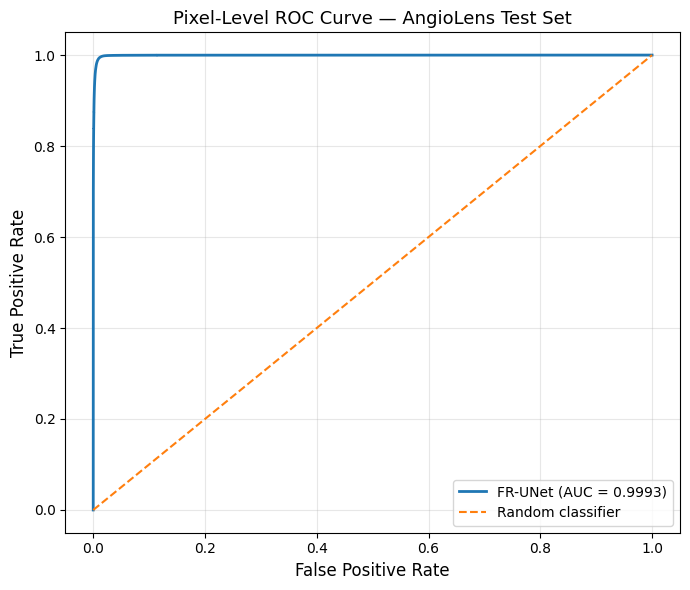

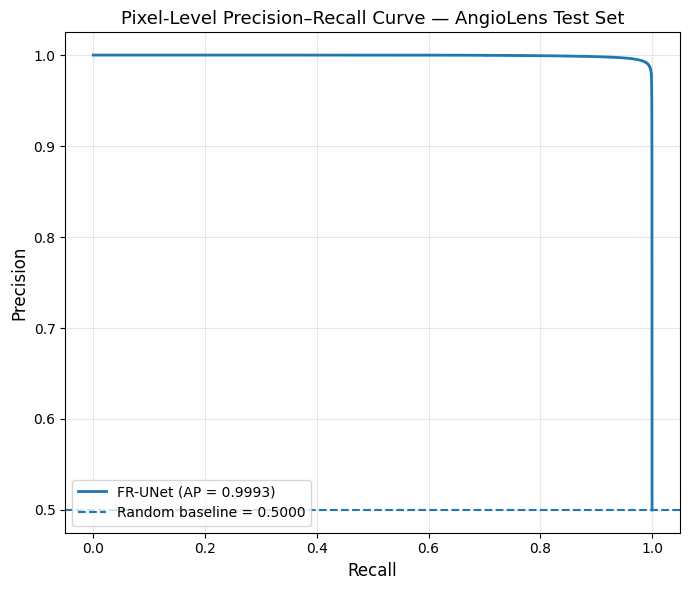


RESULTS SAVED
ROC figure:
/content/drive/MyDrive/angio_ai_project/AngioLens_FRUNet_Training_Results/final_test_pixel_level_ROC_curve.png

PR figure:
/content/drive/MyDrive/angio_ai_project/AngioLens_FRUNet_Training_Results/final_test_pixel_level_PR_curve.png

Numerical summary:
/content/drive/MyDrive/angio_ai_project/AngioLens_FRUNet_Training_Results/final_test_ROC_PR_summary.csv

✅ Pixel-level ROC and Precision–Recall analysis completed successfully!


In [18]:
# ============================================================
# STEP 12: PIXEL-LEVEL ROC AND PRECISION-RECALL ANALYSIS
# Fast stratified sampling from saved test probability maps
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.metrics import (
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)


print("=" * 70)
print("PIXEL-LEVEL ROC AND PRECISION-RECALL ANALYSIS")
print("=" * 70)


# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

RANDOM_SEED = 42

# Maximum pixels sampled from each class
MAX_POSITIVE_PIXELS = 500_000
MAX_NEGATIVE_PIXELS = 500_000

rng = np.random.default_rng(RANDOM_SEED)


# ------------------------------------------------------------
# FLATTEN ARRAYS
# ------------------------------------------------------------

y_true_all = test_ground_truths.reshape(-1).astype(np.uint8)
y_score_all = test_probabilities.reshape(-1).astype(np.float32)


print(f"Total pixels available : {len(y_true_all):,}")

positive_indices = np.flatnonzero(y_true_all == 1)
negative_indices = np.flatnonzero(y_true_all == 0)

print(f"Positive pixels        : {len(positive_indices):,}")
print(f"Negative pixels        : {len(negative_indices):,}")


# ------------------------------------------------------------
# STRATIFIED RANDOM SAMPLING
# ------------------------------------------------------------

n_positive = min(
    MAX_POSITIVE_PIXELS,
    len(positive_indices)
)

n_negative = min(
    MAX_NEGATIVE_PIXELS,
    len(negative_indices)
)

sampled_positive_indices = rng.choice(
    positive_indices,
    size=n_positive,
    replace=False
)

sampled_negative_indices = rng.choice(
    negative_indices,
    size=n_negative,
    replace=False
)

sampled_indices = np.concatenate([
    sampled_positive_indices,
    sampled_negative_indices
])

# Shuffle sampled pixels
rng.shuffle(sampled_indices)

y_true_sample = y_true_all[sampled_indices]
y_score_sample = y_score_all[sampled_indices]


print(f"\nSampled positive pixels: {n_positive:,}")
print(f"Sampled negative pixels: {n_negative:,}")
print(f"Total sampled pixels   : {len(sampled_indices):,}")


# ------------------------------------------------------------
# ROC CURVE
# ------------------------------------------------------------

fpr, tpr, roc_thresholds = roc_curve(
    y_true_sample,
    y_score_sample
)

roc_auc = auc(fpr, tpr)


# ------------------------------------------------------------
# PRECISION-RECALL CURVE
# ------------------------------------------------------------

pr_precision, pr_recall, pr_thresholds = (
    precision_recall_curve(
        y_true_sample,
        y_score_sample
    )
)

pr_auc = auc(
    pr_recall,
    pr_precision
)

average_precision = average_precision_score(
    y_true_sample,
    y_score_sample
)


# ------------------------------------------------------------
# PRINT RESULTS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("ROC AND PR RESULTS")
print("=" * 70)

print(f"ROC-AUC           : {roc_auc:.6f}")
print(f"PR-AUC            : {pr_auc:.6f}")
print(f"Average Precision : {average_precision:.6f}")


# ------------------------------------------------------------
# OUTPUT DIRECTORY
# ------------------------------------------------------------

output_dir = Path(TRAINING_RESULTS_ROOT)

roc_figure_path = (
    output_dir /
    "final_test_pixel_level_ROC_curve.png"
)

pr_figure_path = (
    output_dir /
    "final_test_pixel_level_PR_curve.png"
)

curve_summary_path = (
    output_dir /
    "final_test_ROC_PR_summary.csv"
)


# ------------------------------------------------------------
# ROC FIGURE
# ------------------------------------------------------------

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"FR-UNet (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random classifier"
)

plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)

plt.title(
    "Pixel-Level ROC Curve — AngioLens Test Set",
    fontsize=13
)

plt.legend(loc="lower right")

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    roc_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# PRECISION-RECALL FIGURE
# ------------------------------------------------------------

plt.figure(figsize=(7, 6))

plt.plot(
    pr_recall,
    pr_precision,
    linewidth=2,
    label=f"FR-UNet (AP = {average_precision:.4f})"
)

baseline = y_true_sample.mean()

plt.axhline(
    baseline,
    linestyle="--",
    linewidth=1.5,
    label=f"Random baseline = {baseline:.4f}"
)

plt.xlabel("Recall", fontsize=12)
plt.ylabel("Precision", fontsize=12)

plt.title(
    "Pixel-Level Precision–Recall Curve — AngioLens Test Set",
    fontsize=13
)

plt.legend(loc="lower left")

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    pr_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# SAVE NUMERICAL SUMMARY
# ------------------------------------------------------------

roc_pr_summary = pd.DataFrame([{
    "ROC_AUC": roc_auc,
    "PR_AUC": pr_auc,
    "Average_Precision": average_precision,
    "Sampled_Positive_Pixels": n_positive,
    "Sampled_Negative_Pixels": n_negative,
    "Total_Sampled_Pixels": len(sampled_indices),
    "Random_Seed": RANDOM_SEED
}])

roc_pr_summary.to_csv(
    curve_summary_path,
    index=False
)


print("\n" + "=" * 70)
print("RESULTS SAVED")
print("=" * 70)

print(f"ROC figure:\n{roc_figure_path}")

print(f"\nPR figure:\n{pr_figure_path}")

print(f"\nNumerical summary:\n{curve_summary_path}")

print(
    "\n✅ Pixel-level ROC and Precision–Recall "
    "analysis completed successfully!"
)

In [19]:
# ============================================================
# STEP 12: ADVANCED SEGMENTATION METRICS
# Uses arrays already created in STEP 10
# ============================================================

import time
import numpy as np
import pandas as pd

from pathlib import Path
from scipy.ndimage import (
    binary_erosion,
    distance_transform_edt
)

print("=" * 70)
print("ADVANCED SEGMENTATION METRICS")
print("=" * 70)

print(f"Test images : {len(test_predictions)}")
print("Using saved predictions — no new inference needed ✅")


# ------------------------------------------------------------
# HELPER FUNCTIONS
# ------------------------------------------------------------

def safe_divide(numerator, denominator):
    return numerator / (denominator + 1e-8)


def calculate_cldice(pred, gt):

    pred = pred.astype(bool)
    gt = gt.astype(bool)

    if not pred.any() and not gt.any():
        return 1.0

    if not pred.any() or not gt.any():
        return 0.0

    # Skeletonization
    from skimage.morphology import skeletonize

    pred_skeleton = skeletonize(pred)
    gt_skeleton = skeletonize(gt)

    tprec = safe_divide(
        np.sum(pred_skeleton & gt),
        np.sum(pred_skeleton)
    )

    tsens = safe_divide(
        np.sum(gt_skeleton & pred),
        np.sum(gt_skeleton)
    )

    return float(
        safe_divide(
            2.0 * tprec * tsens,
            tprec + tsens
        )
    )


def calculate_surface_distances(pred, gt):

    pred = pred.astype(bool)
    gt = gt.astype(bool)

    if not pred.any() or not gt.any():
        return np.nan, np.nan

    pred_surface = pred ^ binary_erosion(pred)
    gt_surface = gt ^ binary_erosion(gt)

    if not pred_surface.any() or not gt_surface.any():
        return np.nan, np.nan

    distance_to_gt = distance_transform_edt(
        ~gt_surface
    )

    distance_to_pred = distance_transform_edt(
        ~pred_surface
    )

    pred_to_gt = distance_to_gt[pred_surface]
    gt_to_pred = distance_to_pred[gt_surface]

    all_distances = np.concatenate([
        pred_to_gt,
        gt_to_pred
    ])

    hd95 = float(
        np.percentile(all_distances, 95)
    )

    assd = float(
        (
            np.mean(pred_to_gt)
            + np.mean(gt_to_pred)
        ) / 2.0
    )

    return hd95, assd


# ------------------------------------------------------------
# CALCULATE METRICS PER IMAGE
# ------------------------------------------------------------

advanced_results = []

start_time = time.time()

for index in range(len(test_predictions)):

    pred = test_predictions[index].astype(bool)
    gt = test_ground_truths[index].astype(bool)
    prob = test_probabilities[index].astype(np.float32)

    tp = np.sum(pred & gt)
    fp = np.sum(pred & (~gt))
    fn = np.sum((~pred) & gt)
    tn = np.sum((~pred) & (~gt))

    sensitivity = safe_divide(tp, tp + fn)
    specificity = safe_divide(tn, tn + fp)

    balanced_accuracy = (
        sensitivity + specificity
    ) / 2.0

    mcc_numerator = (
        tp * tn - fp * fn
    )

    mcc_denominator = np.sqrt(
        float(tp + fp)
        * float(tp + fn)
        * float(tn + fp)
        * float(tn + fn)
    )

    mcc = safe_divide(
        mcc_numerator,
        mcc_denominator
    )

    cldice = calculate_cldice(pred, gt)

    hd95, assd = calculate_surface_distances(
        pred,
        gt
    )

    brier_score = float(
        np.mean(
            (
                prob - gt.astype(np.float32)
            ) ** 2
        )
    )

    predicted_coverage = float(
        np.mean(pred)
    )

    ground_truth_coverage = float(
        np.mean(gt)
    )

    relative_path = test_relative_paths[index]

    category = Path(
        relative_path
    ).parts[0]

    advanced_results.append({

        "Relative_Path": relative_path,
        "Category": category,

        "Balanced_Accuracy": float(
            balanced_accuracy
        ),

        "MCC": float(mcc),

        "clDice": float(cldice),

        "HD95": hd95,

        "ASSD": assd,

        "Brier_Score": brier_score,

        "Predicted_Coverage": predicted_coverage,

        "Ground_Truth_Coverage": ground_truth_coverage
    })


# ------------------------------------------------------------
# CREATE DATAFRAME
# ------------------------------------------------------------

advanced_metrics_df = pd.DataFrame(
    advanced_results
)


# ------------------------------------------------------------
# PRINT FINAL SUMMARY
# ------------------------------------------------------------

elapsed = time.time() - start_time

print("\n" + "=" * 70)
print("FINAL ADVANCED METRICS")
print("=" * 70)

advanced_metric_columns = [
    "Balanced_Accuracy",
    "MCC",
    "clDice",
    "HD95",
    "ASSD",
    "Brier_Score",
    "Predicted_Coverage",
    "Ground_Truth_Coverage"
]

for metric in advanced_metric_columns:

    values = advanced_metrics_df[
        metric
    ].dropna()

    print(
        f"{metric:<24}: "
        f"{values.mean():.6f} ± "
        f"{values.std():.6f}"
    )


# ------------------------------------------------------------
# RESULTS BY CATEGORY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("ADVANCED METRICS BY CATEGORY")
print("=" * 70)

for category in sorted(
    advanced_metrics_df["Category"].unique()
):

    subset = advanced_metrics_df[
        advanced_metrics_df["Category"]
        == category
    ]

    print(f"\n{category}")
    print("-" * 50)
    print(f"Images: {len(subset)}")

    for metric in advanced_metric_columns:

        values = subset[metric].dropna()

        print(
            f"{metric:<24}: "
            f"{values.mean():.6f} ± "
            f"{values.std():.6f}"
        )


# ------------------------------------------------------------
# SAVE RESULTS
# ------------------------------------------------------------

advanced_output_path = (
    Path(TRAINING_RESULTS_ROOT)
    / "final_test_advanced_metrics.csv"
)

advanced_metrics_df.to_csv(
    advanced_output_path,
    index=False
)


print("\n" + "=" * 70)
print("RESULTS SAVED")
print("=" * 70)

print(advanced_output_path)

print(
    f"\nTotal calculation time: "
    f"{elapsed / 60:.2f} minutes"
)

print(
    "\n✅ Advanced segmentation metrics "
    "completed successfully!"
)

ADVANCED SEGMENTATION METRICS
Test images : 503
Using saved predictions — no new inference needed ✅

FINAL ADVANCED METRICS
Balanced_Accuracy       : 0.972617 ± 0.007766
MCC                     : 0.936281 ± 0.017528
clDice                  : 0.947847 ± 0.020736
HD95                    : 2.412210 ± 4.968483
ASSD                    : 0.947638 ± 0.845855
Brier_Score             : 0.003868 ± 0.001680
Predicted_Coverage      : 0.040131 ± 0.011436
Ground_Truth_Coverage   : 0.039289 ± 0.011030

ADVANCED METRICS BY CATEGORY

Normal
--------------------------------------------------
Images: 25
Balanced_Accuracy       : 0.976301 ± 0.005457
MCC                     : 0.946930 ± 0.014997
clDice                  : 0.967350 ± 0.012493
HD95                    : 1.219148 ± 0.400101
ASSD                    : 0.478073 ± 0.153338
Brier_Score             : 0.003013 ± 0.001138
Predicted_Coverage      : 0.037971 ± 0.009732
Ground_Truth_Coverage   : 0.037465 ± 0.009616

Post-treatment
------------------------

PIXEL-LEVEL ROC AND PRECISION-RECALL ANALYSIS
Test images : 503
Using saved probability maps — no new inference needed ✅

Total pixels available : 131,858,432
Positive pixels        : 5,180,524
Negative pixels        : 126,677,908

Sampled positive pixels: 500,000
Sampled negative pixels: 500,000
Total sampled pixels   : 1,000,000

PIXEL-LEVEL CURVE RESULTS
ROC-AUC           : 0.999298
Average Precision : 0.999296


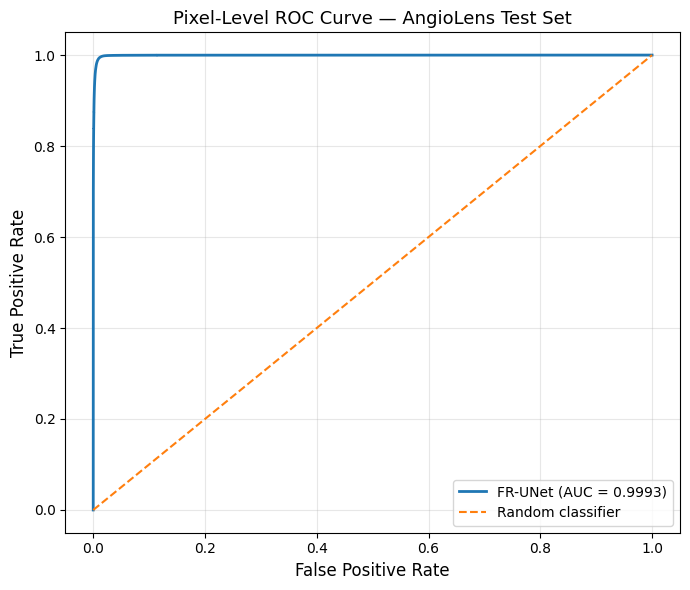

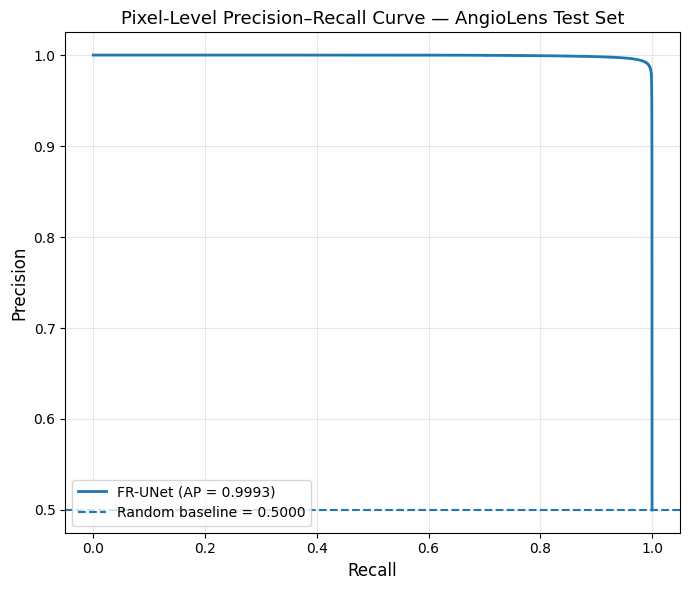


RESULTS SAVED
ROC figure:
/content/drive/MyDrive/angio_ai_project/AngioLens_FRUNet_Training_Results/final_test_pixel_level_ROC_curve.png

PR figure:
/content/drive/MyDrive/angio_ai_project/AngioLens_FRUNet_Training_Results/final_test_pixel_level_PR_curve.png

Numerical summary:
/content/drive/MyDrive/angio_ai_project/AngioLens_FRUNet_Training_Results/pixel_curve_metrics.csv

✅ Pixel-level ROC and Precision–Recall analysis completed successfully!


In [20]:
# ============================================================
# STEP 13: PIXEL-LEVEL ROC AND PRECISION-RECALL ANALYSIS
# Uses saved test probabilities and ground truths
# No new inference needed
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
)


print("=" * 70)
print("PIXEL-LEVEL ROC AND PRECISION-RECALL ANALYSIS")
print("=" * 70)

print(f"Test images : {len(test_probabilities)}")
print("Using saved probability maps — no new inference needed ✅")


# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

RANDOM_SEED = 42

# Fast, memory-safe stratified sample
MAX_POSITIVE_PIXELS = 500_000
MAX_NEGATIVE_PIXELS = 500_000

rng = np.random.default_rng(RANDOM_SEED)


# ------------------------------------------------------------
# FLATTEN SAVED ARRAYS
# ------------------------------------------------------------

y_true_all = (
    test_ground_truths
    .reshape(-1)
    .astype(np.uint8)
)

y_score_all = (
    test_probabilities
    .reshape(-1)
    .astype(np.float32)
)


print(f"\nTotal pixels available : {len(y_true_all):,}")


# ------------------------------------------------------------
# FIND POSITIVE AND NEGATIVE PIXELS
# ------------------------------------------------------------

positive_indices = np.flatnonzero(
    y_true_all == 1
)

negative_indices = np.flatnonzero(
    y_true_all == 0
)

print(
    f"Positive pixels        : "
    f"{len(positive_indices):,}"
)

print(
    f"Negative pixels        : "
    f"{len(negative_indices):,}"
)


# ------------------------------------------------------------
# STRATIFIED RANDOM SAMPLING
# ------------------------------------------------------------

n_positive = min(
    MAX_POSITIVE_PIXELS,
    len(positive_indices)
)

n_negative = min(
    MAX_NEGATIVE_PIXELS,
    len(negative_indices)
)


sampled_positive_indices = rng.choice(
    positive_indices,
    size=n_positive,
    replace=False
)

sampled_negative_indices = rng.choice(
    negative_indices,
    size=n_negative,
    replace=False
)


sampled_indices = np.concatenate([
    sampled_positive_indices,
    sampled_negative_indices
])

rng.shuffle(sampled_indices)


y_true_sample = y_true_all[
    sampled_indices
]

y_score_sample = y_score_all[
    sampled_indices
]


print(
    f"\nSampled positive pixels: "
    f"{n_positive:,}"
)

print(
    f"Sampled negative pixels: "
    f"{n_negative:,}"
)

print(
    f"Total sampled pixels   : "
    f"{len(sampled_indices):,}"
)


# ------------------------------------------------------------
# ROC ANALYSIS
# ------------------------------------------------------------

fpr, tpr, roc_thresholds = roc_curve(
    y_true_sample,
    y_score_sample
)

roc_auc = roc_auc_score(
    y_true_sample,
    y_score_sample
)


# ------------------------------------------------------------
# PRECISION-RECALL ANALYSIS
# ------------------------------------------------------------

pr_precision, pr_recall, pr_thresholds = (
    precision_recall_curve(
        y_true_sample,
        y_score_sample
    )
)

average_precision = average_precision_score(
    y_true_sample,
    y_score_sample
)


# ------------------------------------------------------------
# DISPLAY NUMERICAL RESULTS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("PIXEL-LEVEL CURVE RESULTS")
print("=" * 70)

print(
    f"ROC-AUC           : "
    f"{roc_auc:.6f}"
)

print(
    f"Average Precision : "
    f"{average_precision:.6f}"
)


# ------------------------------------------------------------
# OUTPUT PATHS
# ------------------------------------------------------------

output_dir = Path(
    TRAINING_RESULTS_ROOT
)

roc_figure_path = (
    output_dir
    / "final_test_pixel_level_ROC_curve.png"
)

pr_figure_path = (
    output_dir
    / "final_test_pixel_level_PR_curve.png"
)

curve_summary_path = (
    output_dir
    / "pixel_curve_metrics.csv"
)


# ------------------------------------------------------------
# ROC CURVE
# ------------------------------------------------------------

plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=(
        f"FR-UNet "
        f"(AUC = {roc_auc:.4f})"
    )
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Random classifier"
)

plt.xlabel(
    "False Positive Rate",
    fontsize=12
)

plt.ylabel(
    "True Positive Rate",
    fontsize=12
)

plt.title(
    "Pixel-Level ROC Curve — AngioLens Test Set",
    fontsize=13
)

plt.legend(
    loc="lower right"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    roc_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# PRECISION-RECALL CURVE
# ------------------------------------------------------------

plt.figure(figsize=(7, 6))

plt.plot(
    pr_recall,
    pr_precision,
    linewidth=2,
    label=(
        f"FR-UNet "
        f"(AP = {average_precision:.4f})"
    )
)

random_baseline = (
    y_true_sample.mean()
)

plt.axhline(
    random_baseline,
    linestyle="--",
    linewidth=1.5,
    label=(
        f"Random baseline = "
        f"{random_baseline:.4f}"
    )
)

plt.xlabel(
    "Recall",
    fontsize=12
)

plt.ylabel(
    "Precision",
    fontsize=12
)

plt.title(
    "Pixel-Level Precision–Recall Curve — AngioLens Test Set",
    fontsize=13
)

plt.legend(
    loc="lower left"
)

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.savefig(
    pr_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# SAVE NUMERICAL SUMMARY
# ------------------------------------------------------------

pixel_curve_metrics_df = pd.DataFrame([{

    "ROC_AUC": roc_auc,

    "Average_Precision": (
        average_precision
    ),

    "Sampled_Positive_Pixels": (
        n_positive
    ),

    "Sampled_Negative_Pixels": (
        n_negative
    ),

    "Total_Sampled_Pixels": (
        len(sampled_indices)
    ),

    "Random_Seed": RANDOM_SEED
}])


pixel_curve_metrics_df.to_csv(
    curve_summary_path,
    index=False
)


# ------------------------------------------------------------
# FINAL SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("RESULTS SAVED")
print("=" * 70)

print(
    f"ROC figure:\n"
    f"{roc_figure_path}"
)

print(
    f"\nPR figure:\n"
    f"{pr_figure_path}"
)

print(
    f"\nNumerical summary:\n"
    f"{curve_summary_path}"
)

print(
    "\n✅ Pixel-level ROC and Precision–Recall "
    "analysis completed successfully!"
)

PIXEL-LEVEL CONFUSION MATRIX
Total evaluated pixels : 131,858,432

Confusion Matrix
[[126298749    379159]
 [   268037   4912487]]

Counts
TP : 4,912,487
FP : 379,159
FN : 268,037
TN : 126,298,749

Percentages
TP : 3.7256%
FP : 0.2876%
FN : 0.2033%
TN : 95.7836%


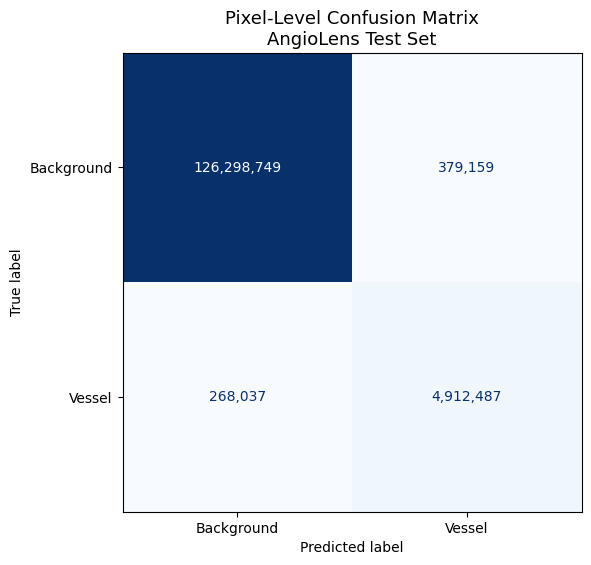


Saved to:
/content/drive/MyDrive/angio_ai_project/AngioLens_FRUNet_Training_Results/pixel_confusion_matrix.png

✅ STEP 14 Completed Successfully


In [21]:
# ============================================================
# STEP 14: PIXEL-LEVEL CONFUSION MATRIX
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("=" * 70)
print("PIXEL-LEVEL CONFUSION MATRIX")
print("=" * 70)

# ------------------------------------------------------------
# Flatten predictions
# ------------------------------------------------------------

y_true = test_ground_truths.reshape(-1)
y_pred = test_predictions.reshape(-1)

print(f"Total evaluated pixels : {len(y_true):,}")

# ------------------------------------------------------------
# Confusion Matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=[0,1]
)

tn, fp, fn, tp = cm.ravel()

print("\nConfusion Matrix")
print(cm)

print("\nCounts")
print(f"TP : {tp:,}")
print(f"FP : {fp:,}")
print(f"FN : {fn:,}")
print(f"TN : {tn:,}")

# ------------------------------------------------------------
# Percentages
# ------------------------------------------------------------

total = cm.sum()

print("\nPercentages")

print(f"TP : {100*tp/total:.4f}%")
print(f"FP : {100*fp/total:.4f}%")
print(f"FN : {100*fn/total:.4f}%")
print(f"TN : {100*tn/total:.4f}%")

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(6,6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Background",
        "Vessel"
    ]
)

disp.plot(
    cmap="Blues",
    ax=ax,
    colorbar=False,
    values_format=","
)

plt.title(
    "Pixel-Level Confusion Matrix\nAngioLens Test Set",
    fontsize=13
)

plt.tight_layout()

output_path = (
    Path(TRAINING_RESULTS_ROOT)
    / "pixel_confusion_matrix.png"
)

plt.savefig(
    output_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("\nSaved to:")
print(output_path)

print("\n✅ STEP 14 Completed Successfully")

In [22]:
import pandas as pd

history = pd.read_csv(
    TRAINING_RESULTS_ROOT + "/training_history.csv"
)

print(history.columns)

display(history.head())

Index(['epoch', 'learning_rate', 'train_loss', 'train_bce_loss',
       'train_dice_loss', 'train_dice', 'train_iou', 'train_precision',
       'train_recall', 'val_loss', 'val_bce_loss', 'val_dice_loss', 'val_dice',
       'val_iou', 'val_precision', 'val_recall', 'epoch_seconds'],
      dtype='object')


,epoch,learning_rate,train_loss,train_bce_loss,train_dice_loss,train_dice,train_iou,train_precision,train_recall,val_loss,val_bce_loss,val_dice_loss,val_dice,val_iou,val_precision,val_recall,epoch_seconds
0,1,0.00001,0.089475,0.025460,0.153491,0.883073,0.792490,0.877152,0.894889,0.062672,0.018034,0.107311,0.918040,0.849289,0.886547,0.953127,591.102793
1,2,0.00001,0.074888,0.023905,0.125872,0.894965,0.811270,0.889882,0.904504,0.055990,0.016174,0.095806,0.925518,0.861955,0.912650,0.939621,590.457233
2,3,0.00001,0.071272,0.023460,0.119085,0.898805,0.817404,0.894152,0.907258,0.056360,0.017014,0.095705,0.922679,0.857094,0.901599,0.946019,590.037697
3,4,0.00001,0.069536,0.023309,0.115763,0.900605,0.820407,0.895789,0.909244,0.054708,0.016678,0.092738,0.924918,0.861061,0.900661,0.951869,589.092139
4,5,0.00001,0.067417,0.022810,0.112024,0.903131,0.824470,0.899142,0.910454,0.052847,0.016643,0.089050,0.926792,0.864174,0.902508,0.953497,589.792134


TRAINING CURVES


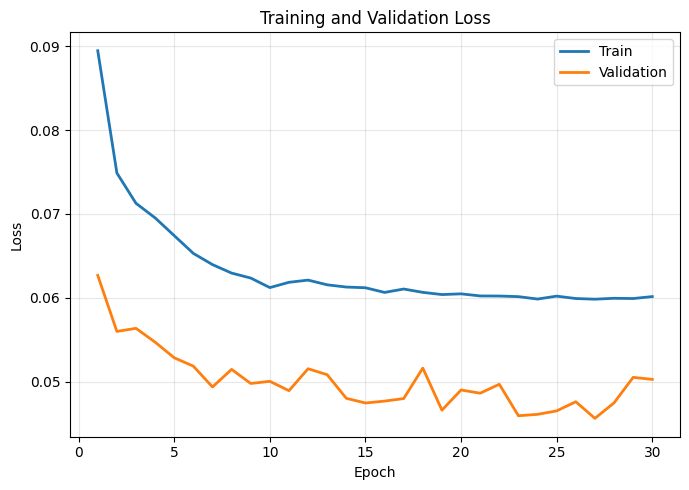

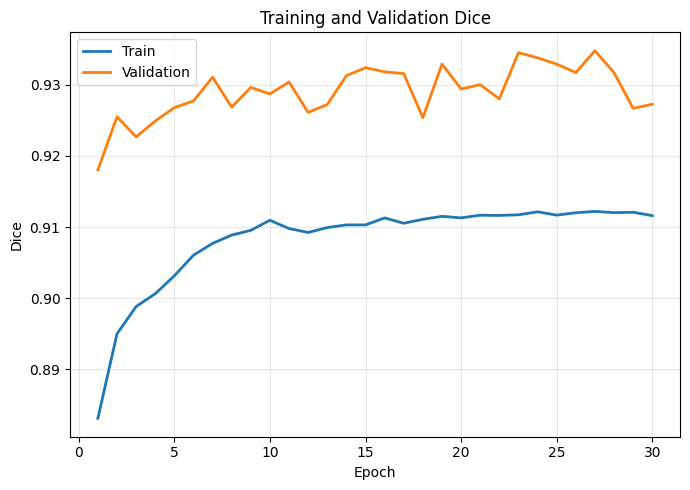

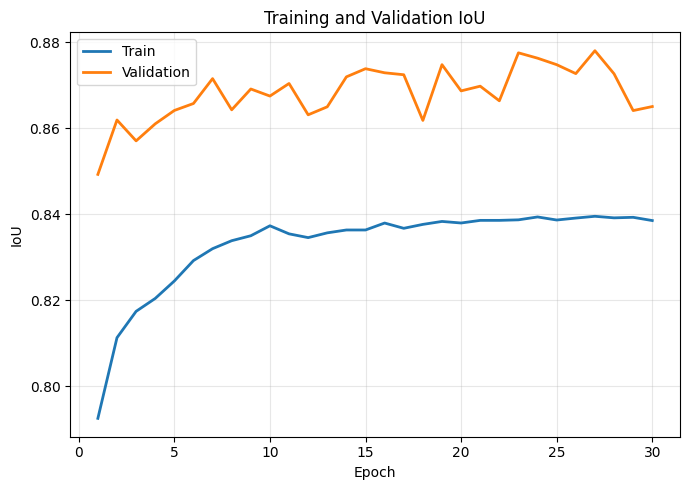

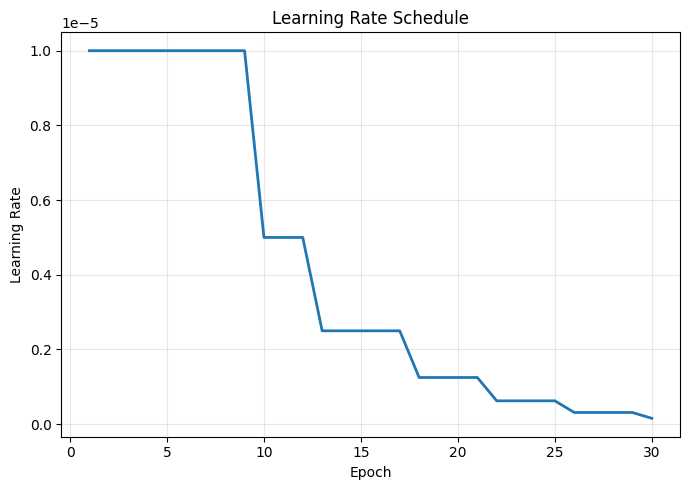

TRAINING CURVES COMPLETED
Saved figures:
/content/drive/MyDrive/angio_ai_project/AngioLens_FRUNet_Training_Results/training_validation_loss.png
/content/drive/MyDrive/angio_ai_project/AngioLens_FRUNet_Training_Results/training_validation_dice.png
/content/drive/MyDrive/angio_ai_project/AngioLens_FRUNet_Training_Results/training_validation_iou.png
/content/drive/MyDrive/angio_ai_project/AngioLens_FRUNet_Training_Results/learning_rate_schedule.png


In [23]:
# ============================================================
# STEP 15: TRAINING CURVES
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

print("=" * 70)
print("TRAINING CURVES")
print("=" * 70)

history = pd.read_csv(
    Path(TRAINING_RESULTS_ROOT) /
    "training_history.csv"
)

output_dir = Path(TRAINING_RESULTS_ROOT)

# ------------------------------------------------------------
# 1. LOSS
# ------------------------------------------------------------

plt.figure(figsize=(7,5))

plt.plot(
    history["epoch"],
    history["train_loss"],
    linewidth=2,
    label="Train"
)

plt.plot(
    history["epoch"],
    history["val_loss"],
    linewidth=2,
    label="Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()

plt.savefig(
    output_dir/"training_validation_loss.png",
    dpi=300
)

plt.show()

# ------------------------------------------------------------
# 2. DICE
# ------------------------------------------------------------

plt.figure(figsize=(7,5))

plt.plot(
    history["epoch"],
    history["train_dice"],
    linewidth=2,
    label="Train"
)

plt.plot(
    history["epoch"],
    history["val_dice"],
    linewidth=2,
    label="Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.title("Training and Validation Dice")

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()

plt.savefig(
    output_dir/"training_validation_dice.png",
    dpi=300
)

plt.show()

# ------------------------------------------------------------
# 3. IoU
# ------------------------------------------------------------

plt.figure(figsize=(7,5))

plt.plot(
    history["epoch"],
    history["train_iou"],
    linewidth=2,
    label="Train"
)

plt.plot(
    history["epoch"],
    history["val_iou"],
    linewidth=2,
    label="Validation"
)

plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.title("Training and Validation IoU")

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()

plt.savefig(
    output_dir/"training_validation_iou.png",
    dpi=300
)

plt.show()

# ------------------------------------------------------------
# 4. LEARNING RATE
# ------------------------------------------------------------

plt.figure(figsize=(7,5))

plt.plot(
    history["epoch"],
    history["learning_rate"],
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Learning Rate Schedule")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    output_dir/"learning_rate_schedule.png",
    dpi=300
)

plt.show()

print("=" * 70)
print("TRAINING CURVES COMPLETED")
print("=" * 70)

print("Saved figures:")

print(output_dir/"training_validation_loss.png")
print(output_dir/"training_validation_dice.png")
print(output_dir/"training_validation_iou.png")
print(output_dir/"learning_rate_schedule.png")

METRIC DISTRIBUTIONS & FAILURE ANALYSIS


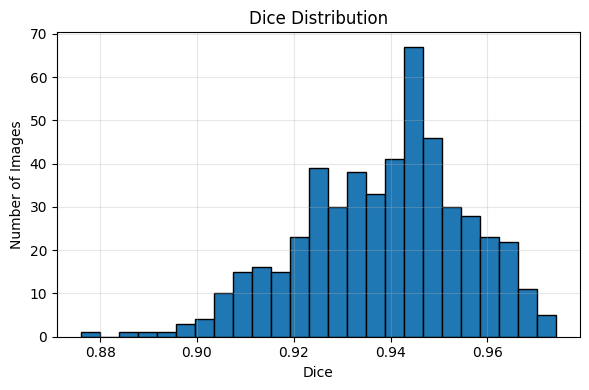

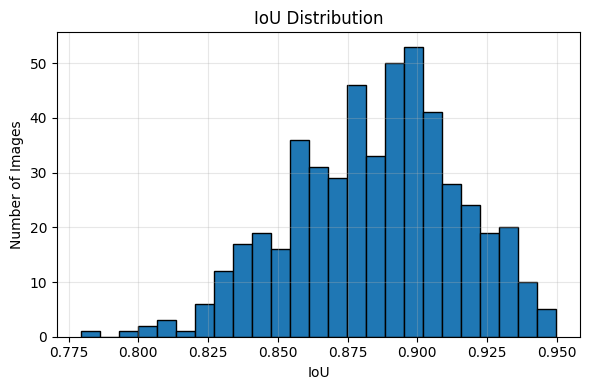

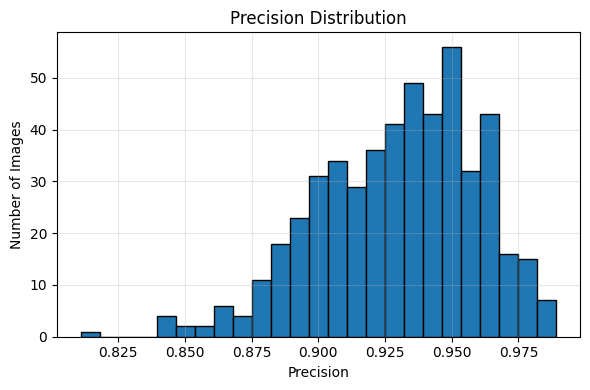

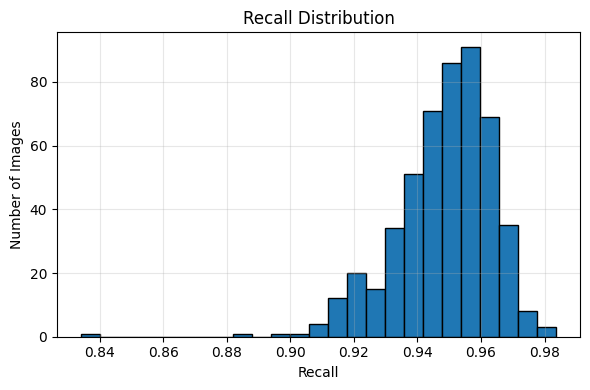

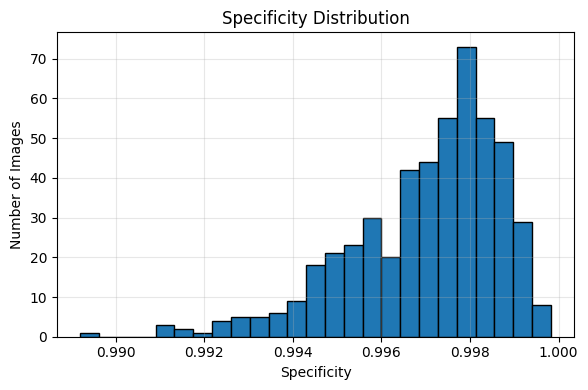

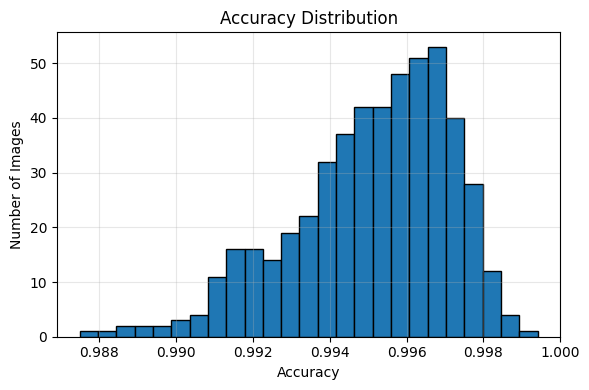

/tmp/ipykernel_567/2737287268.py:67: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


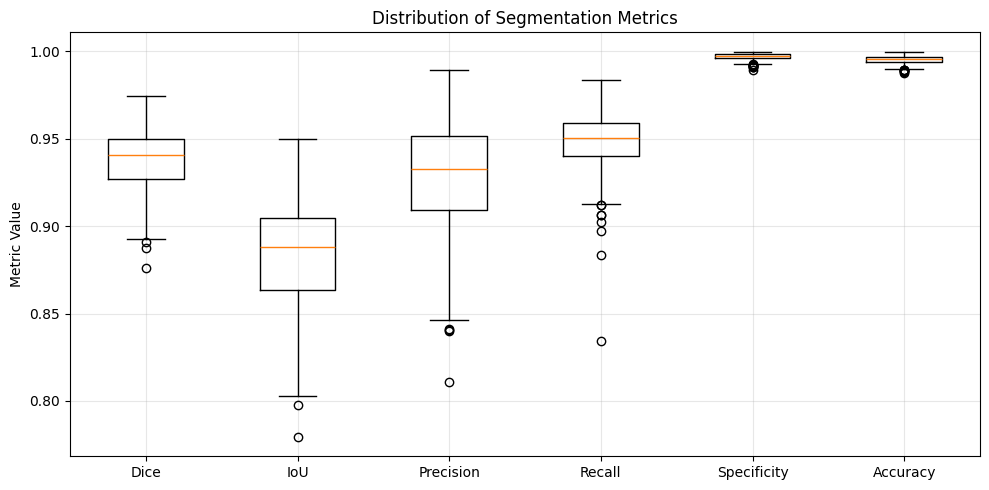

FAILURE ANALYSIS
Dice Q1        : 0.9268
Dice Q3        : 0.9499
IQR            : 0.0231
Lower Bound    : 0.8922

Outlier Images : 3


,Relative_Path,Category,Dice,IoU,Precision,Recall
262,Pre-treatment/3/ST24/S9/frame_02.png,Pre-treatment,0.875993,0.779348,0.810955,0.952373
193,Pre-treatment/1/ST2/S8/frame_00.png,Pre-treatment,0.887528,0.797799,0.948319,0.834062
76,Post-treatment/3/ST25/S30/frame_06.png,Post-treatment,0.890753,0.803024,0.852210,0.932946



Saved:
/content/drive/MyDrive/angio_ai_project/AngioLens_FRUNet_Training_Results/failure_analysis.csv

✅ STEP 16 COMPLETED


In [24]:
# ============================================================
# STEP 16: METRIC DISTRIBUTIONS & FAILURE ANALYSIS
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

print("=" * 70)
print("METRIC DISTRIBUTIONS & FAILURE ANALYSIS")
print("=" * 70)

output_dir = Path(TRAINING_RESULTS_ROOT)

# ------------------------------------------------------------
# LOAD PER-IMAGE METRICS
# ------------------------------------------------------------

metrics_df = test_results_df.copy()

metrics = [
    "Dice",
    "IoU",
    "Precision",
    "Recall",
    "Specificity",
    "Accuracy"
]

# ------------------------------------------------------------
# HISTOGRAMS
# ------------------------------------------------------------

for metric in metrics:

    plt.figure(figsize=(6,4))

    plt.hist(
        metrics_df[metric],
        bins=25,
        edgecolor="black"
    )

    plt.xlabel(metric)
    plt.ylabel("Number of Images")
    plt.title(f"{metric} Distribution")

    plt.grid(alpha=0.3)

    plt.tight_layout()

    plt.savefig(
        output_dir/f"{metric.lower()}_distribution.png",
        dpi=300
    )

    plt.show()

# ------------------------------------------------------------
# BOXPLOT
# ------------------------------------------------------------

plt.figure(figsize=(10,5))

plt.boxplot(
    [metrics_df[m] for m in metrics],
    labels=metrics,
    showfliers=True
)

plt.ylabel("Metric Value")
plt.title("Distribution of Segmentation Metrics")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    output_dir/"metric_boxplots.png",
    dpi=300
)

plt.show()

# ------------------------------------------------------------
# OUTLIERS USING IQR
# ------------------------------------------------------------

dice = metrics_df["Dice"]

Q1 = dice.quantile(0.25)
Q3 = dice.quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5*IQR

outliers = metrics_df[
    metrics_df["Dice"] < lower
].copy()

outliers = outliers.sort_values(
    "Dice"
)

print("="*70)
print("FAILURE ANALYSIS")
print("="*70)

print(f"Dice Q1        : {Q1:.4f}")
print(f"Dice Q3        : {Q3:.4f}")
print(f"IQR            : {IQR:.4f}")
print(f"Lower Bound    : {lower:.4f}")

print(f"\nOutlier Images : {len(outliers)}")

if len(outliers)>0:

    display(
        outliers[
            [
                "Relative_Path",
                "Category",
                "Dice",
                "IoU",
                "Precision",
                "Recall"
            ]
        ].head(20)
    )

# ------------------------------------------------------------
# SAVE REPORT
# ------------------------------------------------------------

failure_csv = (
    output_dir /
    "failure_analysis.csv"
)

outliers.to_csv(
    failure_csv,
    index=False
)

print("\nSaved:")
print(failure_csv)

print("\n✅ STEP 16 COMPLETED")

In [25]:
# ============================================================
# STEP 17: AUTOMATIC CASE SELECTION
# Best / Representative / Challenging / Failure Cases
# ============================================================

import numpy as np
import pandas as pd

from pathlib import Path

print("=" * 70)
print("AUTOMATIC CASE SELECTION")
print("=" * 70)

output_dir = Path(TRAINING_RESULTS_ROOT)

# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

CASES_PER_GROUP = 5

# Use the final per-image test results
selection_df = test_results_df.copy()

required_columns = [
    "Relative_Path",
    "Category",
    "Dice",
    "IoU",
    "Precision",
    "Recall",
    "Specificity",
    "Accuracy"
]

missing_columns = [
    column for column in required_columns
    if column not in selection_df.columns
]

if missing_columns:
    raise ValueError(
        "Missing required columns: "
        + ", ".join(missing_columns)
    )

# ------------------------------------------------------------
# ADD ADVANCED METRICS IF AVAILABLE
# ------------------------------------------------------------

if "advanced_metrics_df" in globals():

    advanced_for_merge = advanced_metrics_df.copy()

    advanced_columns = [
        "Relative_Path",
        "Balanced_Accuracy",
        "MCC",
        "clDice",
        "HD95",
        "ASSD",
        "Brier_Score",
        "Predicted_Coverage",
        "Ground_Truth_Coverage"
    ]

    advanced_columns = [
        column for column in advanced_columns
        if column in advanced_for_merge.columns
    ]

    selection_df = selection_df.merge(
        advanced_for_merge[advanced_columns],
        on="Relative_Path",
        how="left"
    )

    print("Advanced metrics merged successfully ✅")

else:
    print(
        "Advanced metrics dataframe not found. "
        "Selection will use basic metrics only."
    )


# ------------------------------------------------------------
# EXTRACT SOURCE GROUP
# Avoid selecting many frames from the same video/group
# ------------------------------------------------------------

def extract_source_group(relative_path):

    parts = Path(relative_path).parts

    # Example:
    # Pre-treatment / 3 / ST24 / S9 / frame_02.png
    # Use all folders except the final frame filename
    if len(parts) > 1:
        return "/".join(parts[:-1])

    return Path(relative_path).stem


selection_df["Source_Group"] = (
    selection_df["Relative_Path"]
    .apply(extract_source_group)
)


# ------------------------------------------------------------
# HELPER: REMOVE DUPLICATE SOURCE GROUPS
# ------------------------------------------------------------

def unique_groups(frame, count):

    return (
        frame
        .drop_duplicates(
            subset="Source_Group",
            keep="first"
        )
        .head(count)
        .copy()
    )


# ------------------------------------------------------------
# 1. BEST CASES
# Highest Dice, then IoU
# ------------------------------------------------------------

best_cases = (
    selection_df
    .sort_values(
        by=["Dice", "IoU", "Precision", "Recall"],
        ascending=[False, False, False, False]
    )
)

best_cases = unique_groups(
    best_cases,
    CASES_PER_GROUP
)


# ------------------------------------------------------------
# 2. REPRESENTATIVE CASES
# Closest to median Dice and median mask coverage
# ------------------------------------------------------------

median_dice = selection_df["Dice"].median()
median_iou = selection_df["IoU"].median()

selection_df["Representative_Distance"] = (
    np.abs(selection_df["Dice"] - median_dice)
    +
    np.abs(selection_df["IoU"] - median_iou)
)

if "Ground_Truth_Coverage" in selection_df.columns:

    median_coverage = (
        selection_df[
            "Ground_Truth_Coverage"
        ].median()
    )

    selection_df[
        "Representative_Distance"
    ] += (
        0.5
        * np.abs(
            selection_df[
                "Ground_Truth_Coverage"
            ]
            - median_coverage
        )
    )

representative_cases = (
    selection_df
    .sort_values(
        by=[
            "Representative_Distance",
            "Dice"
        ],
        ascending=[True, False]
    )
)

representative_cases = unique_groups(
    representative_cases,
    CASES_PER_GROUP
)


# ------------------------------------------------------------
# 3. CHALLENGING CASES
# Lower-performing, but not necessarily extreme failures
# Select close to the first quartile Dice
# ------------------------------------------------------------

dice_q1 = selection_df["Dice"].quantile(0.25)
dice_median = selection_df["Dice"].median()

challenging_pool = selection_df[
    (selection_df["Dice"] >= dice_q1)
    &
    (selection_df["Dice"] <= dice_median)
].copy()

challenging_pool["Challenge_Distance"] = (
    np.abs(
        challenging_pool["Dice"]
        - dice_q1
    )
)

challenging_cases = (
    challenging_pool
    .sort_values(
        by=[
            "Challenge_Distance",
            "IoU"
        ],
        ascending=[True, True]
    )
)

challenging_cases = unique_groups(
    challenging_cases,
    CASES_PER_GROUP
)


# ------------------------------------------------------------
# 4. FAILURE CASES
# Lowest Dice and IoU
# ------------------------------------------------------------

failure_cases = (
    selection_df
    .sort_values(
        by=[
            "Dice",
            "IoU",
            "Precision",
            "Recall"
        ],
        ascending=[
            True,
            True,
            True,
            True
        ]
    )
)

failure_cases = unique_groups(
    failure_cases,
    CASES_PER_GROUP
)


# ------------------------------------------------------------
# ADD SELECTION LABELS AND RANKS
# ------------------------------------------------------------

def prepare_group(frame, group_name):

    frame = frame.copy()

    frame.insert(
        0,
        "Selection_Group",
        group_name
    )

    frame.insert(
        1,
        "Selection_Rank",
        range(1, len(frame) + 1)
    )

    return frame


best_cases = prepare_group(
    best_cases,
    "Best"
)

representative_cases = prepare_group(
    representative_cases,
    "Representative"
)

challenging_cases = prepare_group(
    challenging_cases,
    "Challenging"
)

failure_cases = prepare_group(
    failure_cases,
    "Failure"
)


# ------------------------------------------------------------
# COMBINE ALL SELECTED CASES
# ------------------------------------------------------------

selected_cases_df = pd.concat(
    [
        best_cases,
        representative_cases,
        challenging_cases,
        failure_cases
    ],
    ignore_index=True
)


# ------------------------------------------------------------
# DISPLAY RESULTS
# ------------------------------------------------------------

display_columns = [
    "Selection_Group",
    "Selection_Rank",
    "Relative_Path",
    "Category",
    "Dice",
    "IoU",
    "Precision",
    "Recall"
]

for optional_column in [
    "clDice",
    "HD95",
    "ASSD",
    "MCC"
]:
    if optional_column in selected_cases_df.columns:
        display_columns.append(optional_column)


print("\n" + "=" * 70)
print("BEST CASES")
print("=" * 70)

display(
    best_cases[
        display_columns
    ]
)


print("\n" + "=" * 70)
print("REPRESENTATIVE CASES")
print("=" * 70)

display(
    representative_cases[
        display_columns
    ]
)


print("\n" + "=" * 70)
print("CHALLENGING CASES")
print("=" * 70)

display(
    challenging_cases[
        display_columns
    ]
)


print("\n" + "=" * 70)
print("FAILURE CASES")
print("=" * 70)

display(
    failure_cases[
        display_columns
    ]
)


# ------------------------------------------------------------
# SAVE SEPARATE CSV FILES
# ------------------------------------------------------------

best_output = (
    output_dir /
    "selected_best_cases.csv"
)

representative_output = (
    output_dir /
    "selected_representative_cases.csv"
)

challenging_output = (
    output_dir /
    "selected_challenging_cases.csv"
)

failure_output = (
    output_dir /
    "selected_failure_cases.csv"
)

combined_output = (
    output_dir /
    "selected_cases_all_groups.csv"
)


best_cases.to_csv(
    best_output,
    index=False
)

representative_cases.to_csv(
    representative_output,
    index=False
)

challenging_cases.to_csv(
    challenging_output,
    index=False
)

failure_cases.to_csv(
    failure_output,
    index=False
)

selected_cases_df.to_csv(
    combined_output,
    index=False
)


# ------------------------------------------------------------
# FINAL SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CASE SELECTION SUMMARY")
print("=" * 70)

print(
    f"Best cases           : "
    f"{len(best_cases)}"
)

print(
    f"Representative cases : "
    f"{len(representative_cases)}"
)

print(
    f"Challenging cases    : "
    f"{len(challenging_cases)}"
)

print(
    f"Failure cases        : "
    f"{len(failure_cases)}"
)

print(
    f"\nTotal selected cases : "
    f"{len(selected_cases_df)}"
)


print("\nSaved files:")

print(best_output)
print(representative_output)
print(challenging_output)
print(failure_output)
print(combined_output)

print(
    "\n✅ STEP 17 COMPLETED SUCCESSFULLY"
)

AUTOMATIC CASE SELECTION
Advanced metrics merged successfully ✅

BEST CASES


,Selection_Group,Selection_Rank,Relative_Path,Category,Dice,IoU,Precision,Recall,clDice,HD95,ASSD,MCC
211,Best,1,Pre-treatment/2/ST11/S1/frame_04.png,Pre-treatment,0.974232,0.949758,0.967645,0.980909,0.979618,1.0,0.269307,0.973204
183,Best,2,Post-treatment/pcs_notnormal(1)/ST8/Patient_pc...,Post-treatment,0.974085,0.949478,0.984454,0.963931,0.963755,1.0,0.342654,0.973841
308,Best,3,Pre-treatment/4/ST39/S1/frame_02.png,Pre-treatment,0.973570,0.948501,0.986104,0.961351,0.984755,1.0,0.256874,0.972616
452,Best,4,Unique Stenosis Views/4/ST31/S2/frame_01.png,Unique Stenosis Views,0.970215,0.942154,0.962288,0.978275,0.996436,1.0,0.266644,0.969515
151,Best,5,Post-treatment/5/ST45/S23/frame_07.png,Post-treatment,0.969370,0.940560,0.977080,0.961780,0.982074,1.0,0.209360,0.968234



REPRESENTATIVE CASES


,Selection_Group,Selection_Rank,Relative_Path,Category,Dice,IoU,Precision,Recall,clDice,HD95,ASSD,MCC
467,Representative,1,Unique Stenosis Views/4/ST40/S5/frame_01.png,Unique Stenosis Views,0.941015,0.888600,0.925782,0.956757,0.967979,1.414214,0.455741,0.938592
352,Representative,2,Pre-treatment/5/ST45/S6/frame_03.png,Pre-treatment,0.940430,0.887558,0.940640,0.940220,0.943860,2.000000,0.529137,0.937774
490,Representative,3,Unique Stenosis Views/5/ST45/S6/frame_03.png,Unique Stenosis Views,0.940430,0.887558,0.940640,0.940220,0.943860,2.000000,0.529137,0.937774
99,Representative,4,Post-treatment/4/ST36/S10/frame_02.png,Post-treatment,0.939601,0.886083,0.928983,0.950464,0.967569,1.000000,0.727217,0.937159
498,Representative,5,Unique Stenosis Views/5/ST47/S12/frame_03.png,Unique Stenosis Views,0.939724,0.886302,0.927204,0.952587,0.941593,3.000000,1.564364,0.937234



CHALLENGING CASES


,Selection_Group,Selection_Rank,Relative_Path,Category,Dice,IoU,Precision,Recall,clDice,HD95,ASSD,MCC
356,Challenging,1,Pre-treatment/5/ST45/S6/frame_07.png,Pre-treatment,0.926873,0.863712,0.902647,0.952435,0.937317,2.236068,0.848001,0.923801
494,Challenging,2,Unique Stenosis Views/5/ST45/S6/frame_07.png,Unique Stenosis Views,0.926873,0.863712,0.902647,0.952435,0.937317,2.236068,0.848001,0.923801
388,Challenging,3,Unique Stenosis Views/1/ST2/S4/frame_00.png,Unique Stenosis Views,0.927044,0.864009,0.911884,0.942716,0.948361,2.000000,0.900320,0.924013
110,Challenging,4,Post-treatment/4/ST36/S12/frame_07.png,Post-treatment,0.927471,0.864752,0.896618,0.960523,0.949884,2.000000,0.721670,0.925315
399,Challenging,5,Unique Stenosis Views/1/ST4/S3/frame_03.png,Unique Stenosis Views,0.927490,0.864785,0.922858,0.932169,0.955716,2.000000,0.535885,0.923735



FAILURE CASES


,Selection_Group,Selection_Rank,Relative_Path,Category,Dice,IoU,Precision,Recall,clDice,HD95,ASSD,MCC
262,Failure,1,Pre-treatment/3/ST24/S9/frame_02.png,Pre-treatment,0.875993,0.779348,0.810955,0.952373,0.885537,7.810250,1.225102,0.872569
193,Failure,2,Pre-treatment/1/ST2/S8/frame_00.png,Pre-treatment,0.887528,0.797799,0.948319,0.834062,0.879341,103.978238,9.029635,0.885107
76,Failure,3,Post-treatment/3/ST25/S30/frame_06.png,Post-treatment,0.890753,0.803024,0.852210,0.932946,0.875897,8.000000,1.889868,0.885907
216,Failure,4,Pre-treatment/2/ST16/S2/frame_02.png,Pre-treatment,0.892848,0.806437,0.853483,0.936020,0.908730,4.006155,1.300210,0.889647
133,Failure,5,Post-treatment/5/ST41/S26/frame_06.png,Post-treatment,0.896101,0.811759,0.839764,0.960539,0.924011,5.656854,1.100536,0.893381



CASE SELECTION SUMMARY
Best cases           : 5
Representative cases : 5
Challenging cases    : 5
Failure cases        : 5

Total selected cases : 20

Saved files:
/content/drive/MyDrive/angio_ai_project/AngioLens_FRUNet_Training_Results/selected_best_cases.csv
/content/drive/MyDrive/angio_ai_project/AngioLens_FRUNet_Training_Results/selected_representative_cases.csv
/content/drive/MyDrive/angio_ai_project/AngioLens_FRUNet_Training_Results/selected_challenging_cases.csv
/content/drive/MyDrive/angio_ai_project/AngioLens_FRUNet_Training_Results/selected_failure_cases.csv
/content/drive/MyDrive/angio_ai_project/AngioLens_FRUNet_Training_Results/selected_cases_all_groups.csv

✅ STEP 17 COMPLETED SUCCESSFULLY


In [26]:
from pathlib import Path

images_root = Path(FINETUNE_DATASET_ROOT) / "test" / "images"

print(next(images_root.rglob("*.*")))

/content/drive/MyDrive/angio_ai_project/AngioLens_FRUNet_FineTune/test/images/Normal/CD3/ST23/S4/frame_03.png


In [27]:

# ============================================================
# STEP 18: PUBLICATION-READY QUALITATIVE FIGURES
# Original / Ground Truth / Prediction / Probability / Overlay / Error Map
# ============================================================

import cv2
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

print("=" * 70)
print("PUBLICATION-READY QUALITATIVE FIGURES")
print("=" * 70)

# ------------------------------------------------------------
# REQUIRED VARIABLES CHECK
# ------------------------------------------------------------

required_variables = [
    "FINETUNE_DATASET_ROOT",
    "TRAINING_RESULTS_ROOT",
    "test_probabilities",
    "test_ground_truths",
    "test_predictions",
    "test_relative_paths"
]

missing_variables = [
    name for name in required_variables
    if name not in globals()
]

if missing_variables:
    raise RuntimeError(
        "Missing variables: "
        + ", ".join(missing_variables)
        + "\nRun STEP 10 first in the current Colab session."
    )

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

dataset_root = Path(FINETUNE_DATASET_ROOT)
test_images_root = dataset_root / "test" / "images"
test_masks_root = dataset_root / "test" / "masks"

output_root = (
    Path(TRAINING_RESULTS_ROOT)
    / "publication_qualitative_figures"
)

individual_dir = output_root / "individual_cases"
group_dir = output_root / "group_montages"

individual_dir.mkdir(parents=True, exist_ok=True)
group_dir.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# LOAD SELECTED CASES
# ------------------------------------------------------------

if "selected_cases_df" in globals():
    selected_cases = selected_cases_df.copy()
else:
    selected_cases_path = (
        Path(TRAINING_RESULTS_ROOT)
        / "selected_cases_all_groups.csv"
    )

    if not selected_cases_path.exists():
        raise FileNotFoundError(
            f"Selected-cases file not found:\n{selected_cases_path}\n"
            "Run STEP 17 first."
        )

    selected_cases = pd.read_csv(selected_cases_path)

selected_cases["Relative_Path"] = (
    selected_cases["Relative_Path"]
    .astype(str)
    .str.replace("\\\\", "/", regex=False)
)

print(f"Selected cases loaded: {len(selected_cases)}")

# ------------------------------------------------------------
# BUILD ARRAY INDEX LOOKUP
# ------------------------------------------------------------

path_to_index = {
    str(path).replace("\\", "/"): index
    for index, path in enumerate(test_relative_paths)
}

# ------------------------------------------------------------
# HELPER FUNCTIONS
# ------------------------------------------------------------

def safe_filename(text):
    text = str(text)
    text = re.sub(r"[^A-Za-z0-9._-]+", "_", text)
    return text.strip("_")


def read_original_image(relative_path):
    image_path = test_images_root / Path(relative_path)

    image = cv2.imread(
        str(image_path),
        cv2.IMREAD_GRAYSCALE
    )

    if image is None:
        raise FileNotFoundError(
            f"Original image not found:\n{image_path}"
        )

    image = cv2.resize(
        image,
        (512, 512),
        interpolation=cv2.INTER_LINEAR
    )

    return image


def read_original_mask(relative_path):
    mask_path = (
        test_masks_root
        / Path(relative_path).with_suffix(".png")
    )

    mask = cv2.imread(
        str(mask_path),
        cv2.IMREAD_GRAYSCALE
    )

    if mask is None:
        raise FileNotFoundError(
            f"Ground-truth mask not found:\n{mask_path}"
        )

    mask = cv2.resize(
        mask,
        (512, 512),
        interpolation=cv2.INTER_NEAREST
    )

    return (mask > 127).astype(np.uint8)


def make_overlay(image, gt, pred):
    base = cv2.cvtColor(
        image,
        cv2.COLOR_GRAY2RGB
    ).astype(np.float32)

    overlay = base.copy()

    # Ground truth = green
    gt_color = np.zeros_like(overlay)
    gt_color[..., 1] = 255

    # Prediction = red
    pred_color = np.zeros_like(overlay)
    pred_color[..., 0] = 255

    alpha = 0.45

    gt_mask = gt.astype(bool)
    pred_mask = pred.astype(bool)

    overlay[gt_mask] = (
        (1 - alpha) * overlay[gt_mask]
        + alpha * gt_color[gt_mask]
    )

    overlay[pred_mask] = (
        (1 - alpha) * overlay[pred_mask]
        + alpha * pred_color[pred_mask]
    )

    return np.clip(
        overlay,
        0,
        255
    ).astype(np.uint8)


def make_error_map(gt, pred):
    error_map = np.zeros(
        (*gt.shape, 3),
        dtype=np.uint8
    )

    tp = (gt == 1) & (pred == 1)
    fp = (gt == 0) & (pred == 1)
    fn = (gt == 1) & (pred == 0)

    # TP = white
    error_map[tp] = [255, 255, 255]

    # FP = red
    error_map[fp] = [255, 0, 0]

    # FN = blue
    error_map[fn] = [0, 120, 255]

    return error_map


def get_case_data(row):
    relative_path = str(
        row["Relative_Path"]
    ).replace("\\", "/")

    if relative_path not in path_to_index:
        raise KeyError(
            f"Relative path not found in STEP 10 arrays:\n"
            f"{relative_path}"
        )

    index = path_to_index[relative_path]

    image = read_original_image(relative_path)

    # Use the original disk mask for visualization
    gt_disk = read_original_mask(relative_path)

    probability = np.asarray(
        test_probabilities[index],
        dtype=np.float32
    )

    gt = np.asarray(
        test_ground_truths[index],
        dtype=np.uint8
    )

    pred = np.asarray(
        test_predictions[index],
        dtype=np.uint8
    )

    # Safety check
    if not np.array_equal(gt, gt_disk):
        print(
            f"Warning: resized disk mask differs slightly "
            f"from cached ground truth for {relative_path}"
        )

    overlay = make_overlay(
        image,
        gt,
        pred
    )

    error_map = make_error_map(
        gt,
        pred
    )

    return {
        "relative_path": relative_path,
        "image": image,
        "gt": gt,
        "pred": pred,
        "probability": probability,
        "overlay": overlay,
        "error_map": error_map
    }


# ------------------------------------------------------------
# CREATE ONE FIGURE PER SELECTED CASE
# ------------------------------------------------------------

saved_individual_figures = []

for _, row in selected_cases.iterrows():

    case = get_case_data(row)

    selection_group = row["Selection_Group"]
    selection_rank = int(row["Selection_Rank"])
    category = row["Category"]

    dice = float(row["Dice"])
    iou = float(row["IoU"])

    fig, axes = plt.subplots(
        1,
        6,
        figsize=(19, 4.2)
    )

    axes[0].imshow(
        case["image"],
        cmap="gray"
    )
    axes[0].set_title("Original")

    axes[1].imshow(
        case["gt"],
        cmap="gray",
        vmin=0,
        vmax=1
    )
    axes[1].set_title("Ground Truth")

    axes[2].imshow(
        case["pred"],
        cmap="gray",
        vmin=0,
        vmax=1
    )
    axes[2].set_title("Prediction")

    probability_plot = axes[3].imshow(
        case["probability"],
        cmap="viridis",
        vmin=0,
        vmax=1
    )
    axes[3].set_title("Probability")

    axes[4].imshow(
        case["overlay"]
    )
    axes[4].set_title("Overlay")

    axes[5].imshow(
        case["error_map"]
    )
    axes[5].set_title("Error Map")

    for axis in axes:
        axis.axis("off")

    colorbar = fig.colorbar(
        probability_plot,
        ax=axes[3],
        fraction=0.046,
        pad=0.04
    )
    colorbar.ax.tick_params(
        labelsize=8
    )

    legend_elements = [
        Patch(
            facecolor="white",
            edgecolor="black",
            label="True Positive"
        ),
        Patch(
            facecolor="red",
            edgecolor="black",
            label="False Positive"
        ),
        Patch(
            facecolor=(0, 120/255, 1),
            edgecolor="black",
            label="False Negative"
        )
    ]

    axes[5].legend(
        handles=legend_elements,
        loc="lower center",
        bbox_to_anchor=(0.5, -0.20),
        ncol=1,
        fontsize=7,
        frameon=True
    )

    figure_title = (
        f"{selection_group} Case {selection_rank} | "
        f"{category} | Dice={dice:.4f} | IoU={iou:.4f}"
    )

    fig.suptitle(
        figure_title,
        fontsize=14,
        fontweight="bold",
        y=1.03
    )

    plt.tight_layout()

    output_name = (
        f"{selection_group.lower()}_"
        f"{selection_rank:02d}_"
        f"{safe_filename(category)}_"
        f"{safe_filename(Path(case['relative_path']).stem)}.png"
    )

    output_path = (
        individual_dir
        / output_name
    )

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close(fig)

    saved_individual_figures.append(
        output_path
    )

print(
    f"Individual figures saved: "
    f"{len(saved_individual_figures)}"
)

# ------------------------------------------------------------
# CREATE GROUP MONTAGES
# One row per case, six columns per row
# ------------------------------------------------------------

group_order = [
    "Best",
    "Representative",
    "Challenging",
    "Failure"
]

saved_group_figures = []

for group_name in group_order:

    group_cases = (
        selected_cases[
            selected_cases["Selection_Group"]
            == group_name
        ]
        .sort_values("Selection_Rank")
        .copy()
    )

    if len(group_cases) == 0:
        continue

    fig, axes = plt.subplots(
        len(group_cases),
        6,
        figsize=(18, 3.2 * len(group_cases)),
        squeeze=False
    )

    column_titles = [
        "Original",
        "Ground Truth",
        "Prediction",
        "Probability",
        "Overlay",
        "Error Map"
    ]

    for column, title in enumerate(column_titles):
        axes[0, column].set_title(
            title,
            fontsize=12,
            fontweight="bold"
        )

    probability_image = None

    for row_index, (_, row) in enumerate(
        group_cases.iterrows()
    ):

        case = get_case_data(row)

        axes[row_index, 0].imshow(
            case["image"],
            cmap="gray"
        )

        axes[row_index, 1].imshow(
            case["gt"],
            cmap="gray",
            vmin=0,
            vmax=1
        )

        axes[row_index, 2].imshow(
            case["pred"],
            cmap="gray",
            vmin=0,
            vmax=1
        )

        probability_image = axes[row_index, 3].imshow(
            case["probability"],
            cmap="viridis",
            vmin=0,
            vmax=1
        )

        axes[row_index, 4].imshow(
            case["overlay"]
        )

        axes[row_index, 5].imshow(
            case["error_map"]
        )

        row_label = (
            f"Rank {int(row['Selection_Rank'])}\n"
            f"{row['Category']}\n"
            f"Dice={float(row['Dice']):.4f}\n"
            f"IoU={float(row['IoU']):.4f}"
        )

        axes[row_index, 0].set_ylabel(
            row_label,
            fontsize=9,
            fontweight="bold"
        )

        for column in range(6):
            axes[row_index, column].set_xticks([])
            axes[row_index, column].set_yticks([])

    fig.suptitle(
        f"{group_name} Cases — AngioLens FR-UNet",
        fontsize=16,
        fontweight="bold",
        y=1.01
    )

    if probability_image is not None:
        fig.colorbar(
            probability_image,
            ax=axes[:, 3],
            fraction=0.015,
            pad=0.02
        )

    legend_elements = [
        Patch(
            facecolor="white",
            edgecolor="black",
            label="True Positive"
        ),
        Patch(
            facecolor="red",
            edgecolor="black",
            label="False Positive"
        ),
        Patch(
            facecolor=(0, 120/255, 1),
            edgecolor="black",
            label="False Negative"
        )
    ]

    fig.legend(
        handles=legend_elements,
        loc="lower center",
        ncol=3,
        bbox_to_anchor=(0.5, -0.01),
        fontsize=9,
        frameon=True
    )

    plt.tight_layout(
        rect=[0, 0.03, 1, 0.98]
    )

    group_output_path = (
        group_dir
        / f"{group_name.lower()}_cases_montage.png"
    )

    plt.savefig(
        group_output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close(fig)

    saved_group_figures.append(
        group_output_path
    )

# ------------------------------------------------------------
# SAVE FIGURE MANIFEST
# ------------------------------------------------------------

figure_manifest = []

for _, row in selected_cases.iterrows():

    group_name = row["Selection_Group"]
    rank = int(row["Selection_Rank"])
    category = row["Category"]

    relative_path = str(
        row["Relative_Path"]
    ).replace("\\", "/")

    filename_pattern = (
        f"{group_name.lower()}_"
        f"{rank:02d}_"
        f"{safe_filename(category)}_"
        f"{safe_filename(Path(relative_path).stem)}.png"
    )

    figure_manifest.append({
        "Selection_Group": group_name,
        "Selection_Rank": rank,
        "Category": category,
        "Relative_Path": relative_path,
        "Dice": float(row["Dice"]),
        "IoU": float(row["IoU"]),
        "Figure_Path": str(
            individual_dir
            / filename_pattern
        )
    })

figure_manifest_df = pd.DataFrame(
    figure_manifest
)

manifest_path = (
    output_root
    / "qualitative_figure_manifest.csv"
)

figure_manifest_df.to_csv(
    manifest_path,
    index=False
)

# ------------------------------------------------------------
# FINAL SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STEP 18 COMPLETED SUCCESSFULLY")
print("=" * 70)

print(
    f"Individual figures : "
    f"{len(saved_individual_figures)}"
)

print(
    f"Group montages     : "
    f"{len(saved_group_figures)}"
)

print(
    f"\nOutput folder:\n"
    f"{output_root}"
)

print(
    f"\nManifest:\n"
    f"{manifest_path}"
)

print(
    "\n✅ Publication-ready qualitative figures "
    "were created successfully!"
)


PUBLICATION-READY QUALITATIVE FIGURES
Selected cases loaded: 20
Individual figures saved: 20


/tmp/ipykernel_567/2173051908.py:578: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(



STEP 18 COMPLETED SUCCESSFULLY
Individual figures : 20
Group montages     : 4

Output folder:
/content/drive/MyDrive/angio_ai_project/AngioLens_FRUNet_Training_Results/publication_qualitative_figures

Manifest:
/content/drive/MyDrive/angio_ai_project/AngioLens_FRUNet_Training_Results/publication_qualitative_figures/qualitative_figure_manifest.csv

✅ Publication-ready qualitative figures were created successfully!


In [28]:
# ============================================================
# STEP 19: FINAL PUBLICATION PACKAGE
# CSV + Excel + LaTeX + Summary + ZIP
# ============================================================

import json
import shutil
import numpy as np
import pandas as pd

from pathlib import Path
from datetime import datetime

print("=" * 70)
print("CREATING FINAL PUBLICATION PACKAGE")
print("=" * 70)


# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

results_root = Path(TRAINING_RESULTS_ROOT)

final_package_dir = (
    results_root
    / "AngioLens_FRUNet_Final_Publication_Package"
)

tables_dir = final_package_dir / "tables"
latex_dir = final_package_dir / "latex"
reports_dir = final_package_dir / "reports"
figures_dir = final_package_dir / "figures"

for folder in [
    final_package_dir,
    tables_dir,
    latex_dir,
    reports_dir,
    figures_dir
]:
    folder.mkdir(
        parents=True,
        exist_ok=True
    )


# ------------------------------------------------------------
# HELPER FUNCTIONS
# ------------------------------------------------------------

def load_csv_if_needed(
    variable_name,
    filename
):
    if variable_name in globals():

        data = globals()[variable_name]

        if isinstance(data, pd.DataFrame):
            return data.copy()

    file_path = results_root / filename

    if file_path.exists():
        return pd.read_csv(file_path)

    print(
        f"Warning: file not found: "
        f"{file_path}"
    )

    return pd.DataFrame()


def copy_if_exists(
    source,
    destination_folder
):
    source = Path(source)

    if source.exists():

        destination = (
            destination_folder
            / source.name
        )

        shutil.copy2(
            source,
            destination
        )

        return destination

    return None


def format_ci(
    mean_value,
    lower,
    upper
):
    return (
        f"{mean_value:.6f} "
        f"[{lower:.6f}, {upper:.6f}]"
    )


# ------------------------------------------------------------
# LOAD ALL RESULTS
# ------------------------------------------------------------

test_metrics_df = load_csv_if_needed(
    "test_results_df",
    "final_test_per_image_metrics_threshold_055.csv"
)

advanced_df = load_csv_if_needed(
    "advanced_metrics_df",
    "final_test_advanced_metrics.csv"
)

bootstrap_df = load_csv_if_needed(
    "bootstrap_ci_df",
    "final_test_bootstrap_95CI.csv"
)

threshold_df = load_csv_if_needed(
    "threshold_results",
    "validation_threshold_optimization.csv"
)

selected_df = load_csv_if_needed(
    "selected_cases_df",
    "selected_cases_all_groups.csv"
)

pixel_curve_df = load_csv_if_needed(
    "pixel_curve_metrics_df",
    "pixel_curve_metrics.csv"
)

training_history_df = load_csv_if_needed(
    "history",
    "training_history.csv"
)

failure_df = load_csv_if_needed(
    "outliers",
    "failure_analysis.csv"
)

figure_manifest_df = pd.DataFrame()

figure_manifest_path = (
    results_root
    / "publication_qualitative_figures"
    / "qualitative_figure_manifest.csv"
)

if figure_manifest_path.exists():

    figure_manifest_df = pd.read_csv(
        figure_manifest_path
    )


# ------------------------------------------------------------
# MERGE BASIC AND ADVANCED PER-IMAGE METRICS
# ------------------------------------------------------------

final_per_image_df = (
    test_metrics_df.copy()
)

if (
    not advanced_df.empty
    and "Relative_Path" in advanced_df.columns
):

    advanced_columns = [
        column
        for column in advanced_df.columns
        if column not in [
            "Category"
        ]
    ]

    final_per_image_df = (
        final_per_image_df.merge(
            advanced_df[
                advanced_columns
            ],
            on="Relative_Path",
            how="left"
        )
    )


# ------------------------------------------------------------
# FINAL OVERALL METRICS TABLE
# ------------------------------------------------------------

basic_metrics = [
    "Dice",
    "IoU",
    "Precision",
    "Recall",
    "Specificity",
    "Accuracy"
]

advanced_metrics = [
    "Balanced_Accuracy",
    "MCC",
    "clDice",
    "HD95",
    "ASSD",
    "Brier_Score",
    "Predicted_Coverage",
    "Ground_Truth_Coverage"
]

overall_rows = []

for metric in (
    basic_metrics
    + advanced_metrics
):

    if metric not in final_per_image_df.columns:
        continue

    values = (
        final_per_image_df[
            metric
        ]
        .dropna()
        .astype(float)
    )

    row = {
        "Metric": metric,
        "N": len(values),
        "Mean": values.mean(),
        "Standard_Deviation": values.std(),
        "Median": values.median(),
        "Minimum": values.min(),
        "Maximum": values.max(),
        "Q1": values.quantile(0.25),
        "Q3": values.quantile(0.75)
    }

    if (
        not bootstrap_df.empty
        and "Metric" in bootstrap_df.columns
        and metric in bootstrap_df[
            "Metric"
        ].values
    ):

        ci_row = bootstrap_df[
            bootstrap_df["Metric"]
            == metric
        ].iloc[0]

        row["CI_95_Lower"] = (
            ci_row["CI_95_Lower"]
        )

        row["CI_95_Upper"] = (
            ci_row["CI_95_Upper"]
        )

    else:

        row["CI_95_Lower"] = np.nan
        row["CI_95_Upper"] = np.nan

    overall_rows.append(row)


overall_metrics_df = pd.DataFrame(
    overall_rows
)


# ------------------------------------------------------------
# CATEGORY SUMMARY
# ------------------------------------------------------------

category_metric_columns = [
    metric
    for metric in (
        basic_metrics
        + advanced_metrics
    )
    if metric in final_per_image_df.columns
]

category_summary_rows = []

for category in sorted(
    final_per_image_df[
        "Category"
    ].dropna().unique()
):

    subset = final_per_image_df[
        final_per_image_df[
            "Category"
        ] == category
    ]

    for metric in category_metric_columns:

        values = (
            subset[metric]
            .dropna()
            .astype(float)
        )

        category_summary_rows.append({
            "Category": category,
            "Metric": metric,
            "N": len(values),
            "Mean": values.mean(),
            "Standard_Deviation": (
                values.std()
            ),
            "Median": values.median(),
            "Minimum": values.min(),
            "Maximum": values.max()
        })


final_category_summary_df = pd.DataFrame(
    category_summary_rows
)


# ------------------------------------------------------------
# MAIN PUBLICATION TABLE
# ------------------------------------------------------------

publication_metrics = [
    "Dice",
    "IoU",
    "Precision",
    "Recall",
    "Specificity",
    "Accuracy",
    "Balanced_Accuracy",
    "MCC",
    "clDice",
    "HD95",
    "ASSD",
    "Brier_Score"
]

publication_rows = []

for metric in publication_metrics:

    match = overall_metrics_df[
        overall_metrics_df[
            "Metric"
        ] == metric
    ]

    if match.empty:
        continue

    row = match.iloc[0]

    ci_text = ""

    if (
        not pd.isna(
            row["CI_95_Lower"]
        )
        and not pd.isna(
            row["CI_95_Upper"]
        )
    ):

        ci_text = format_ci(
            row["Mean"],
            row["CI_95_Lower"],
            row["CI_95_Upper"]
        )

    else:

        ci_text = (
            f"{row['Mean']:.6f} "
            f"± "
            f"{row['Standard_Deviation']:.6f}"
        )

    publication_rows.append({
        "Metric": metric,
        "Mean": row["Mean"],
        "Standard Deviation": (
            row[
                "Standard_Deviation"
            ]
        ),
        "95% CI": ci_text
    })


publication_table_df = pd.DataFrame(
    publication_rows
)


# ------------------------------------------------------------
# EXPERIMENT SUMMARY
# ------------------------------------------------------------

best_threshold_value = 0.55

if (
    not threshold_df.empty
    and "Mean_Dice" in threshold_df.columns
):

    best_threshold_row = threshold_df.loc[
        threshold_df[
            "Mean_Dice"
        ].idxmax()
    ]

    best_threshold_value = float(
        best_threshold_row[
            "Threshold"
        ]
    )


best_epoch = None
best_val_dice = None

if not training_history_df.empty:

    best_history_index = (
        training_history_df[
            "val_dice"
        ].idxmax()
    )

    best_epoch = int(
        training_history_df.loc[
            best_history_index,
            "epoch"
        ]
    )

    best_val_dice = float(
        training_history_df.loc[
            best_history_index,
            "val_dice"
        ]
    )


experiment_summary_df = pd.DataFrame([{
    "Model": "FR-UNet",
    "Dataset": "AngioLens",
    "Test_Images": len(
        final_per_image_df
    ),
    "Image_Size": "512 × 512",
    "Selected_Threshold": (
        best_threshold_value
    ),
    "Best_Epoch": best_epoch,
    "Best_Validation_Dice": (
        best_val_dice
    ),
    "Evaluation_Date": (
        datetime.now().strftime(
            "%Y-%m-%d %H:%M:%S"
        )
    )
}])


# ------------------------------------------------------------
# SAVE CSV TABLES
# ------------------------------------------------------------

final_per_image_df.to_csv(
    tables_dir
    / "final_per_image_metrics.csv",
    index=False
)

overall_metrics_df.to_csv(
    tables_dir
    / "final_overall_metrics.csv",
    index=False
)

final_category_summary_df.to_csv(
    tables_dir
    / "final_category_metrics.csv",
    index=False
)

publication_table_df.to_csv(
    tables_dir
    / "publication_performance_table.csv",
    index=False
)

experiment_summary_df.to_csv(
    tables_dir
    / "experiment_summary.csv",
    index=False
)

if not threshold_df.empty:

    threshold_df.to_csv(
        tables_dir
        / "threshold_optimization.csv",
        index=False
    )

if not bootstrap_df.empty:

    bootstrap_df.to_csv(
        tables_dir
        / "bootstrap_95CI.csv",
        index=False
    )

if not pixel_curve_df.empty:

    pixel_curve_df.to_csv(
        tables_dir
        / "pixel_curve_metrics.csv",
        index=False
    )

if not selected_df.empty:

    selected_df.to_csv(
        tables_dir
        / "selected_cases.csv",
        index=False
    )

if not failure_df.empty:

    failure_df.to_csv(
        tables_dir
        / "failure_cases.csv",
        index=False
    )

if not figure_manifest_df.empty:

    figure_manifest_df.to_csv(
        tables_dir
        / "qualitative_figure_manifest.csv",
        index=False
    )


# ------------------------------------------------------------
# SAVE EXCEL WORKBOOK
# ------------------------------------------------------------

excel_path = (
    final_package_dir
    / "AngioLens_FRUNet_Final_Results.xlsx"
)

with pd.ExcelWriter(
    excel_path,
    engine="openpyxl"
) as writer:

    experiment_summary_df.to_excel(
        writer,
        sheet_name="Experiment Summary",
        index=False
    )

    publication_table_df.to_excel(
        writer,
        sheet_name="Publication Table",
        index=False
    )

    overall_metrics_df.to_excel(
        writer,
        sheet_name="Overall Metrics",
        index=False
    )

    final_category_summary_df.to_excel(
        writer,
        sheet_name="Category Metrics",
        index=False
    )

    final_per_image_df.to_excel(
        writer,
        sheet_name="Per Image Metrics",
        index=False
    )

    if not bootstrap_df.empty:

        bootstrap_df.to_excel(
            writer,
            sheet_name="Bootstrap CI",
            index=False
        )

    if not threshold_df.empty:

        threshold_df.to_excel(
            writer,
            sheet_name="Threshold Search",
            index=False
        )

    if not pixel_curve_df.empty:

        pixel_curve_df.to_excel(
            writer,
            sheet_name="ROC PR Metrics",
            index=False
        )

    if not selected_df.empty:

        selected_df.to_excel(
            writer,
            sheet_name="Selected Cases",
            index=False
        )

    if not failure_df.empty:

        failure_df.to_excel(
            writer,
            sheet_name="Failure Analysis",
            index=False
        )


# ------------------------------------------------------------
# CREATE LATEX PERFORMANCE TABLE
# ------------------------------------------------------------

latex_metric_names = {
    "Dice": "Dice",
    "IoU": "IoU",
    "Precision": "Precision",
    "Recall": "Recall",
    "Specificity": "Specificity",
    "Accuracy": "Accuracy",
    "Balanced_Accuracy": (
        "Balanced Accuracy"
    ),
    "MCC": "MCC",
    "clDice": "clDice",
    "HD95": "HD95 (pixels)",
    "ASSD": "ASSD (pixels)",
    "Brier_Score": "Brier Score"
}

latex_lines = [
    r"\begin{table}[htbp]",
    r"\centering",
    r"\caption{Final segmentation performance of the fine-tuned FR-UNet model on the AngioLens test set.}",
    r"\label{tab:angio_frunet_final_results}",
    r"\begin{tabular}{lcc}",
    r"\hline",
    r"\textbf{Metric} & \textbf{Mean $\pm$ SD} & \textbf{95\% CI} \\",
    r"\hline"
]

for _, row in overall_metrics_df.iterrows():

    metric = row["Metric"]

    if metric not in latex_metric_names:
        continue

    metric_label = latex_metric_names[
        metric
    ]

    mean_sd = (
        f"{row['Mean']:.4f} "
        f"$\\pm$ "
        f"{row['Standard_Deviation']:.4f}"
    )

    if (
        not pd.isna(
            row["CI_95_Lower"]
        )
        and not pd.isna(
            row["CI_95_Upper"]
        )
    ):

        ci_value = (
            f"[{row['CI_95_Lower']:.4f}, "
            f"{row['CI_95_Upper']:.4f}]"
        )

    else:

        ci_value = "--"

    latex_lines.append(
        f"{metric_label} & "
        f"{mean_sd} & "
        f"{ci_value} \\\\"
    )


latex_lines.extend([
    r"\hline",
    r"\end{tabular}",
    r"\end{table}"
])


latex_table_path = (
    latex_dir
    / "final_performance_table.tex"
)

latex_table_path.write_text(
    "\n".join(latex_lines),
    encoding="utf-8"
)


# ------------------------------------------------------------
# CREATE CATEGORY LATEX TABLE
# ------------------------------------------------------------

category_latex_lines = [
    r"\begin{table*}[htbp]",
    r"\centering",
    r"\caption{FR-UNet segmentation performance across AngioLens categories.}",
    r"\label{tab:angio_category_results}",
    r"\begin{tabular}{lcccc}",
    r"\hline",
    r"\textbf{Category} & \textbf{Images} & \textbf{Dice} & \textbf{IoU} & \textbf{clDice} \\",
    r"\hline"
]

for category in sorted(
    final_per_image_df[
        "Category"
    ].unique()
):

    subset = final_per_image_df[
        final_per_image_df[
            "Category"
        ] == category
    ]

    dice_text = (
        f"{subset['Dice'].mean():.4f} "
        f"$\\pm$ "
        f"{subset['Dice'].std():.4f}"
    )

    iou_text = (
        f"{subset['IoU'].mean():.4f} "
        f"$\\pm$ "
        f"{subset['IoU'].std():.4f}"
    )

    if "clDice" in subset.columns:

        cldice_text = (
            f"{subset['clDice'].mean():.4f} "
            f"$\\pm$ "
            f"{subset['clDice'].std():.4f}"
        )

    else:

        cldice_text = "--"

    safe_category = (
        str(category)
        .replace("&", r"\&")
        .replace("_", r"\_")
    )

    category_latex_lines.append(
        f"{safe_category} & "
        f"{len(subset)} & "
        f"{dice_text} & "
        f"{iou_text} & "
        f"{cldice_text} \\\\"
    )


category_latex_lines.extend([
    r"\hline",
    r"\end{tabular}",
    r"\end{table*}"
])


category_latex_path = (
    latex_dir
    / "category_performance_table.tex"
)

category_latex_path.write_text(
    "\n".join(
        category_latex_lines
    ),
    encoding="utf-8"
)


# ------------------------------------------------------------
# CREATE FINAL TEXT REPORT
# ------------------------------------------------------------

def metric_mean(
    metric_name
):
    match = overall_metrics_df[
        overall_metrics_df[
            "Metric"
        ] == metric_name
    ]

    if match.empty:
        return np.nan

    return float(
        match.iloc[0]["Mean"]
    )


dice_value = metric_mean("Dice")
iou_value = metric_mean("IoU")
precision_value = metric_mean(
    "Precision"
)
recall_value = metric_mean("Recall")
specificity_value = metric_mean(
    "Specificity"
)
accuracy_value = metric_mean(
    "Accuracy"
)
cldice_value = metric_mean("clDice")
mcc_value = metric_mean("MCC")
hd95_value = metric_mean("HD95")
assd_value = metric_mean("ASSD")
brier_value = metric_mean(
    "Brier_Score"
)


report_lines = [
    "ANGIOLENS FR-UNET FINAL EVALUATION REPORT",
    "=" * 60,
    "",
    f"Model: FR-UNet",
    f"Dataset: AngioLens",
    f"Test images: {len(final_per_image_df)}",
    f"Image size: 512 × 512",
    f"Final threshold: {best_threshold_value:.2f}",
    f"Best epoch: {best_epoch}",
    "",
    "FINAL TEST PERFORMANCE",
    "-" * 60,
    f"Dice: {dice_value:.6f}",
    f"IoU: {iou_value:.6f}",
    f"Precision: {precision_value:.6f}",
    f"Recall: {recall_value:.6f}",
    f"Specificity: {specificity_value:.6f}",
    f"Accuracy: {accuracy_value:.6f}",
    f"MCC: {mcc_value:.6f}",
    f"clDice: {cldice_value:.6f}",
    f"HD95: {hd95_value:.6f} pixels",
    f"ASSD: {assd_value:.6f} pixels",
    f"Brier score: {brier_value:.6f}",
    "",
    "FAILURE ANALYSIS",
    "-" * 60,
    f"Statistical outliers: {len(failure_df)}",
    (
        f"Outlier percentage: "
        f"{100 * len(failure_df) / len(final_per_image_df):.2f}%"
        if len(final_per_image_df) > 0
        else "Outlier percentage: N/A"
    ),
    "",
    "OUTPUTS",
    "-" * 60,
    "Per-image metrics",
    "Overall metrics",
    "Category metrics",
    "Bootstrap confidence intervals",
    "Threshold optimization",
    "ROC and precision-recall results",
    "Selected best, representative, challenging and failure cases",
    "Publication-ready qualitative figures",
    "Excel workbook",
    "LaTeX tables",
    "",
    "FINAL STATUS: EVALUATION COMPLETED SUCCESSFULLY",
    "=" * 60
]


report_path = (
    reports_dir
    / "AngioLens_FRUNet_Final_Report.txt"
)

report_path.write_text(
    "\n".join(report_lines),
    encoding="utf-8"
)


# ------------------------------------------------------------
# COPY IMPORTANT FIGURES
# ------------------------------------------------------------

important_figure_names = [
    "final_test_pixel_level_ROC_curve.png",
    "final_test_pixel_level_PR_curve.png",
    "pixel_confusion_matrix.png",
    "training_validation_loss.png",
    "training_validation_dice.png",
    "training_validation_iou.png",
    "learning_rate_schedule.png",
    "dice_distribution.png",
    "iou_distribution.png",
    "precision_distribution.png",
    "recall_distribution.png",
    "specificity_distribution.png",
    "accuracy_distribution.png",
    "metric_boxplots.png"
]

copied_figures = []

for figure_name in important_figure_names:

    copied = copy_if_exists(
        results_root / figure_name,
        figures_dir
    )

    if copied is not None:
        copied_figures.append(
            copied
        )


# ------------------------------------------------------------
# COPY QUALITATIVE FIGURES FOLDER
# ------------------------------------------------------------

qualitative_source = (
    results_root
    / "publication_qualitative_figures"
)

qualitative_destination = (
    figures_dir
    / "publication_qualitative_figures"
)

if qualitative_source.exists():

    if qualitative_destination.exists():
        shutil.rmtree(
            qualitative_destination
        )

    shutil.copytree(
        qualitative_source,
        qualitative_destination
    )


# ------------------------------------------------------------
# SAVE JSON SUMMARY
# ------------------------------------------------------------

summary_json = {
    "model": "FR-UNet",
    "dataset": "AngioLens",
    "test_images": int(
        len(final_per_image_df)
    ),
    "image_size": 512,
    "final_threshold": float(
        best_threshold_value
    ),
    "best_epoch": (
        int(best_epoch)
        if best_epoch is not None
        else None
    ),
    "metrics": {
        "Dice": dice_value,
        "IoU": iou_value,
        "Precision": precision_value,
        "Recall": recall_value,
        "Specificity": specificity_value,
        "Accuracy": accuracy_value,
        "MCC": mcc_value,
        "clDice": cldice_value,
        "HD95": hd95_value,
        "ASSD": assd_value,
        "Brier_Score": brier_value
    },
    "failure_outliers": int(
        len(failure_df)
    ),
    "publication_figures": int(
        len(figure_manifest_df)
    ),
    "created_at": (
        datetime.now().isoformat()
    )
}


json_path = (
    reports_dir
    / "final_summary.json"
)

with open(
    json_path,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        summary_json,
        file,
        indent=4,
        ensure_ascii=False
    )


# ------------------------------------------------------------
# CREATE ZIP ARCHIVE
# ------------------------------------------------------------

zip_base_path = (
    results_root
    / "AngioLens_FRUNet_Final_Publication_Package"
)

zip_path = shutil.make_archive(
    str(zip_base_path),
    "zip",
    root_dir=final_package_dir
)


# ------------------------------------------------------------
# FINAL OUTPUT
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STEP 19 COMPLETED SUCCESSFULLY")
print("=" * 70)

print(
    f"Final package folder:\n"
    f"{final_package_dir}"
)

print(
    f"\nExcel workbook:\n"
    f"{excel_path}"
)

print(
    f"\nLaTeX performance table:\n"
    f"{latex_table_path}"
)

print(
    f"\nLaTeX category table:\n"
    f"{category_latex_path}"
)

print(
    f"\nFinal report:\n"
    f"{report_path}"
)

print(
    f"\nZIP package:\n"
    f"{zip_path}"
)

print(
    f"\nPer-image records: "
    f"{len(final_per_image_df)}"
)

print(
    f"Figures copied: "
    f"{len(copied_figures)}"
)

print(
    "\n🎉 ANGIOLENS FR-UNET FINAL EVALUATION "
    "IS 100% COMPLETE!"
)

CREATING FINAL PUBLICATION PACKAGE

STEP 19 COMPLETED SUCCESSFULLY
Final package folder:
/content/drive/MyDrive/angio_ai_project/AngioLens_FRUNet_Training_Results/AngioLens_FRUNet_Final_Publication_Package

Excel workbook:
/content/drive/MyDrive/angio_ai_project/AngioLens_FRUNet_Training_Results/AngioLens_FRUNet_Final_Publication_Package/AngioLens_FRUNet_Final_Results.xlsx

LaTeX performance table:
/content/drive/MyDrive/angio_ai_project/AngioLens_FRUNet_Training_Results/AngioLens_FRUNet_Final_Publication_Package/latex/final_performance_table.tex

LaTeX category table:
/content/drive/MyDrive/angio_ai_project/AngioLens_FRUNet_Training_Results/AngioLens_FRUNet_Final_Publication_Package/latex/category_performance_table.tex

Final report:
/content/drive/MyDrive/angio_ai_project/AngioLens_FRUNet_Training_Results/AngioLens_FRUNet_Final_Publication_Package/reports/AngioLens_FRUNet_Final_Report.txt

ZIP package:
/content/drive/MyDrive/angio_ai_project/AngioLens_FRUNet_Training_Results/AngioLen